# CReST: Survey-Weighted Population Analysis

Performs survey-weighted population analyses and convergent alignment with official PISA Creative Thinking plausible values using BRR-Fay replicate weights.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# CReST survey-weighted population analysis environment

from pathlib import Path
import json

import numpy as np
import pandas as pd

from scipy.stats import spearmanr


BASE_DIR = Path.cwd()

HANDOFF_DIR = (
    BASE_DIR
    / "processed"
    / "crest_v5_handoff"
)

RESULTS_DIR = (
    BASE_DIR
    / "results"
)

FIG_DIR = (
    BASE_DIR
    / "figures"
)

POP_DIR = (
    RESULTS_DIR
    / "survey_weighted_population"
)

POP_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIG_DIR.mkdir(
    exist_ok=True
)


primary_meta = pd.read_pickle(
    HANDOFF_DIR
    / "primary_meta.pkl"
)

model_context = pd.read_pickle(
    HANDOFF_DIR
    / "model_context.pkl"
)

weights_df = pd.read_pickle(
    HANDOFF_DIR
    / "pisa_weights.pkl"
)


signal_prediction_df = pd.read_pickle(
    RESULTS_DIR
    / "crest_oof_signal_predictions_with_context.pkl"
)


print(
    "Students in primary cohort:",
    len(primary_meta)
)

print(
    "Signal-prediction rows:",
    len(signal_prediction_df)
)

print(
    "Education systems:",
    primary_meta["CNT"].nunique()
)

Students in primary cohort: 142564
Signal-prediction rows: 283170
Education systems: 63


In [ ]:
# Build one out-of-fold CReST cross-item transfer score

pred_wide = (

    signal_prediction_df

    .pivot(
        index="handoff_row_index",
        columns="direction",
        values="prediction"
    )
)


target_wide = (

    signal_prediction_df

    .pivot(
        index="handoff_row_index",
        columns="direction",
        values="target"
    )
)


count_wide = (

    signal_prediction_df

    .pivot(
        index="handoff_row_index",
        columns="direction",
        values="target_item_count"
    )
)


required_directions = [
    "A_to_B",
    "B_to_A"
]


for direction in required_directions:

    assert (
        direction
        in pred_wide.columns
    )


complete_idx = (

    pred_wide[
        required_directions
    ]
    .dropna()
    .index
)


transfer_df = pd.DataFrame(
    {
        "handoff_row_index":
            complete_idx.astype(
                np.int64
            ),

        "prediction_A_to_B":
            pred_wide.loc[
                complete_idx,
                "A_to_B"
            ].to_numpy(),

        "prediction_B_to_A":
            pred_wide.loc[
                complete_idx,
                "B_to_A"
            ].to_numpy(),

        "target_B":
            target_wide.loc[
                complete_idx,
                "A_to_B"
            ].to_numpy(),

        "target_A":
            target_wide.loc[
                complete_idx,
                "B_to_A"
            ].to_numpy(),

        "target_count_B":
            count_wide.loc[
                complete_idx,
                "A_to_B"
            ].to_numpy(),

        "target_count_A":
            count_wide.loc[
                complete_idx,
                "B_to_A"
            ].to_numpy()
    }
)


# Equal halves: 16 items + 16 items
transfer_df[
    "crest_transfer_score"
] = (

    transfer_df[
        "prediction_A_to_B"
    ]

    +

    transfer_df[
        "prediction_B_to_A"
    ]

) / 2.0


# Descriptive validation target only.
# Not used as the population outcome.
transfer_df[
    "observed_crosshalf_target"
] = (

    transfer_df[
        "target_A"
    ]

    +

    transfer_df[
        "target_B"
    ]

) / 2.0


meta_for_merge = (
    primary_meta
    .copy()
)


meta_for_merge[
    "handoff_row_index"
] = np.arange(
    len(
        primary_meta
    ),
    dtype=np.int64
)


transfer_df = transfer_df.merge(

    meta_for_merge,

    on="handoff_row_index",

    how="left",

    validate="one_to_one"
)


print(
    "Primary population-analysis students:",
    len(
        transfer_df
    )
)

print(
    "Coverage of original cohort:",
    f"{100 * len(transfer_df) / len(primary_meta):.3f}%"
)

print(
    "Education systems retained:",
    transfer_df[
        "CNT"
    ].nunique()
)


assert (
    transfer_df[
        "CNT"
    ].nunique()
    == 63
)


transfer_df.to_pickle(
    POP_DIR
    / "crest_transfer_score_oof.pkl"
)

Primary population-analysis students: 140839
Coverage of original cohort: 98.790%
Education systems retained: 63


In [ ]:
# Audit the common CReST transfer score

score = (
    transfer_df[
        "crest_transfer_score"
    ]
    .to_numpy(
        dtype=float
    )
)


a_to_b = (
    transfer_df[
        "prediction_A_to_B"
    ]
    .to_numpy(
        dtype=float
    )
)

b_to_a = (
    transfer_df[
        "prediction_B_to_A"
    ]
    .to_numpy(
        dtype=float
    )
)


direction_rho = float(
    spearmanr(
        a_to_b,
        b_to_a
    ).statistic
)


direction_diff = (
    a_to_b
    -
    b_to_a
)


audit = {
    "n_students":
        int(
            len(
                transfer_df
            )
        ),

    "n_systems":
        int(
            transfer_df[
                "CNT"
            ].nunique()
        ),

    "mean":
        float(
            np.mean(
                score
            )
        ),

    "sd":
        float(
            np.std(
                score,
                ddof=1
            )
        ),

    "minimum":
        float(
            np.min(
                score
            )
        ),

    "p01":
        float(
            np.quantile(
                score,
                0.01
            )
        ),

    "p05":
        float(
            np.quantile(
                score,
                0.05
            )
        ),

    "median":
        float(
            np.median(
                score
            )
        ),

    "p95":
        float(
            np.quantile(
                score,
                0.95
            )
        ),

    "p99":
        float(
            np.quantile(
                score,
                0.99
            )
        ),

    "maximum":
        float(
            np.max(
                score
            )
        ),

    "below_zero_percent":
        float(
            100.0
            *
            np.mean(
                score < 0
            )
        ),

    "above_one_percent":
        float(
            100.0
            *
            np.mean(
                score > 1
            )
        ),

    "A_B_spearman":
        direction_rho,

    "A_minus_B_mean":
        float(
            direction_diff.mean()
        ),

    "A_minus_B_sd":
        float(
            direction_diff.std(
                ddof=1
            )
        )
}


print(
    "CReST CROSS-ITEM TRANSFER SCORE AUDIT"
)

print(
    "=" * 60
)


for key, value in audit.items():

    if isinstance(
        value,
        float
    ):

        print(
            f"{key:>25}: "
            f"{value:.6f}"
        )

    else:

        print(
            f"{key:>25}: "
            f"{value}"
        )


# System-specific coverage
coverage = (

    meta_for_merge[
        [
            "CNT",
            "handoff_row_index"
        ]
    ]

    .merge(
        transfer_df[
            [
                "handoff_row_index"
            ]
        ].assign(
            retained=1
        ),

        on="handoff_row_index",

        how="left"
    )

    .assign(
        retained=lambda d:
            d[
                "retained"
            ].fillna(
                0
            )
    )

    .groupby(
        "CNT",
        as_index=False
    )

    .agg(
        cohort_n=(
            "handoff_row_index",
            "size"
        ),

        retained_n=(
            "retained",
            "sum"
        )
    )
)


coverage[
    "coverage_percent"
] = (
    100.0
    *
    coverage[
        "retained_n"
    ]
    /
    coverage[
        "cohort_n"
    ]
)


print(
    "\nSYSTEM COVERAGE"
)

print(
    "Minimum:",
    f"{coverage['coverage_percent'].min():.3f}%"
)

print(
    "Median:",
    f"{coverage['coverage_percent'].median():.3f}%"
)

print(
    "Maximum:",
    f"{coverage['coverage_percent'].max():.3f}%"
)


coverage.to_csv(
    POP_DIR
    / "crest_transfer_score_system_coverage.csv",
    index=False
)

CReST CROSS-ITEM TRANSFER SCORE AUDIT
               n_students: 140839
                n_systems: 63
                     mean: 0.473460
                       sd: 0.153209
                  minimum: -0.106595
                      p01: 0.125880
                      p05: 0.217529
                   median: 0.484689
                      p95: 0.700183
                      p99: 0.753905
                  maximum: 0.935607
       below_zero_percent: 0.034081
        above_one_percent: 0.000000
             A_B_spearman: 0.712775
           A_minus_B_mean: 0.016291
             A_minus_B_sd: 0.125679

SYSTEM COVERAGE
Minimum: 94.188%
Median: 99.093%
Maximum: 99.837%


In [ ]:
# Attach final and replicate survey weights

replicate_cols = [
    f"W_FSTURWT{i}"
    for i in range(
        1,
        81
    )
]


assert set(
    replicate_cols
).issubset(
    weights_df.columns
)


weight_table = (
    weights_df.copy()
)


weight_table[
    "handoff_row_index"
] = np.arange(
    len(
        weight_table
    ),
    dtype=np.int64
)


analysis_df = transfer_df.merge(

    weight_table[
        [
            "handoff_row_index",
            "CNT",
            "CNTSTUID",
            "W_FSTUWT",
            "SENWT"
        ]
        +
        replicate_cols
    ],

    on=[
        "handoff_row_index",
        "CNT",
        "CNTSTUID"
    ],

    how="left",

    validate="one_to_one"
)


assert (
    analysis_df[
        "W_FSTUWT"
    ]
    .notna()
    .all()
)


assert (
    analysis_df[
        replicate_cols
    ]
    .notna()
    .all()
    .all()
)


print(
    "Population-analysis students:",
    len(
        analysis_df
    )
)

print(
    "Education systems:",
    analysis_df[
        "CNT"
    ].nunique()
)

print(
    "Final weights complete: PASS"
)

print(
    "80 replicate weights complete: PASS"
)


analysis_df.to_pickle(
    POP_DIR
    / "crest_population_analysis_base.pkl"
)

Population-analysis students: 140839
Education systems: 63
Final weights complete: PASS
80 replicate weights complete: PASS


In [ ]:
# PISA BRR-Fay weighted estimators

BRR_FAY_FACTOR = 0.05


def weighted_mean(
    values,
    weights
):

    values = np.asarray(
        values,
        dtype=float
    )

    weights = np.asarray(
        weights,
        dtype=float
    )


    valid = (
        np.isfinite(
            values
        )
        &
        np.isfinite(
            weights
        )
        &
        (
            weights > 0
        )
    )


    values = values[
        valid
    ]

    weights = weights[
        valid
    ]


    if len(
        values
    ) == 0:

        return np.nan


    return float(
        np.sum(
            weights
            *
            values
        )
        /
        np.sum(
            weights
        )
    )


def brr_fay_weighted_mean(
    df,
    value_col
):

    values = df[
        value_col
    ].to_numpy(
        dtype=float
    )


    theta = weighted_mean(

        values,

        df[
            "W_FSTUWT"
        ].to_numpy(
            dtype=float
        )
    )


    replicate_estimates = []


    for col in replicate_cols:

        theta_r = weighted_mean(

            values,

            df[
                col
            ].to_numpy(
                dtype=float
            )
        )


        replicate_estimates.append(
            theta_r
        )


    replicate_estimates = np.asarray(
        replicate_estimates,
        dtype=float
    )


    variance = (
        BRR_FAY_FACTOR
        *
        np.sum(
            (
                replicate_estimates
                -
                theta
            ) ** 2
        )
    )


    se = float(
        np.sqrt(
            variance
        )
    )


    return {
        "estimate":
            float(
                theta
            ),

        "se":
            se,

        "ci_low":
            float(
                theta
                -
                1.96
                *
                se
            ),

        "ci_high":
            float(
                theta
                +
                1.96
                *
                se
            ),

        "variance":
            float(
                variance
            ),

        "n_sample":
            int(
                np.isfinite(
                    values
                ).sum()
            )
    }


print(
    "BRR-Fay factor:",
    BRR_FAY_FACTOR
)

print(
    "Replicate weights:",
    len(
        replicate_cols
    )
)

BRR-Fay factor: 0.05
Replicate weights: 80


In [ ]:
# Survey-weighted system-level CReST transfer-score estimates

system_rows = []


for country in sorted(
    analysis_df[
        "CNT"
    ].unique()
):

    country_df = (
        analysis_df[
            analysis_df[
                "CNT"
            ]
            == country
        ]
    )


    result = (
        brr_fay_weighted_mean(
            country_df,
            "crest_transfer_score"
        )
    )


    system_rows.append(
        {
            "country":
                country,

            **result
        }
    )


system_transfer_estimates = (
    pd.DataFrame(
        system_rows
    )
    .sort_values(
        "estimate"
    )
    .reset_index(
        drop=True
    )
)


system_transfer_estimates.to_csv(

    POP_DIR
    / "crest_system_weighted_transfer_score.csv",

    index=False
)


print(
    "SYSTEM-LEVEL SURVEY-WEIGHTED ESTIMATES"
)

print(
    "=" * 72
)


print(
    system_transfer_estimates[
        [
            "country",
            "estimate",
            "se",
            "ci_low",
            "ci_high",
            "n_sample"
        ]
    ]
    .to_string(
        index=False
    )
)


# Country-equal descriptive aggregate
#
# Variances combined assuming independent national samples:
# Var(mean) = sum(Var_country) / K^2

K = len(
    system_transfer_estimates
)


country_equal_mean = float(
    system_transfer_estimates[
        "estimate"
    ].mean()
)


country_equal_variance = float(

    system_transfer_estimates[
        "variance"
    ].sum()

    /
    (
        K ** 2
    )
)


country_equal_se = float(
    np.sqrt(
        country_equal_variance
    )
)


print(
    "\nCOUNTRY-EQUAL 63-SYSTEM SUMMARY"
)

print(
    "Mean:",
    f"{country_equal_mean:.6f}"
)

print(
    "SE:",
    f"{country_equal_se:.6f}"
)

print(
    "95% CI:",
    (
        f"["
        f"{country_equal_mean - 1.96 * country_equal_se:.6f}, "
        f"{country_equal_mean + 1.96 * country_equal_se:.6f}"
        f"]"
    )
)

SYSTEM-LEVEL SURVEY-WEIGHTED ESTIMATES
country  estimate       se   ci_low  ci_high  n_sample
    TAP  0.167140 0.002407 0.162423 0.171857      1569
    MAC  0.244192 0.004515 0.235342 0.253042      1227
    MAR  0.291311 0.006887 0.277812 0.304811      1851
    UZB  0.343651 0.003404 0.336979 0.350324      1988
    SAU  0.348695 0.003667 0.341507 0.355884      2154
    PHL  0.372249 0.005590 0.361293 0.383206      1940
    ALB  0.375435 0.003835 0.367919 0.382951      1507
    IDN  0.379402 0.005160 0.369289 0.389515      3765
    MNG  0.388117 0.003503 0.381250 0.394983      1922
    JOR  0.389458 0.003767 0.382075 0.396841      2130
    THA  0.390453 0.004757 0.381130 0.399777      2340
    PSE  0.392349 0.003934 0.384637 0.400060      2035
    QAZ  0.400154 0.004375 0.391579 0.408729      1996
    SLV  0.400201 0.004944 0.390510 0.409892      1861
    DOM  0.404210 0.003769 0.396823 0.411597      1936
    BGR  0.406912 0.004886 0.397336 0.416489      1828
    JAM  0.413666 0.005613

In [ ]:
# Attach educational context groups to the population-analysis cohort

context_oof = pd.read_pickle(
    RESULTS_DIR
    / "crest_oof_context_table.pkl"
)


context_cols = [
    "handoff_row_index",
    "HOMEPOS",
    "HOMEPOS_country_percentile",
    "HOMEPOS_quartile",
    "ST004D01T",
    "REPEAT",
    "IMMIG",
    "HOME_TEST_LANG_MATCH"
]


analysis_df = analysis_df.merge(

    context_oof[
        context_cols
    ],

    on="handoff_row_index",

    how="left",

    validate="one_to_one"
)


# Gender
analysis_df[
    "gender_group"
] = analysis_df[
    "ST004D01T"
].map(
    {
        1.0: "Female",
        2.0: "Male"
    }
)


# Grade repetition
analysis_df[
    "repeat_group"
] = analysis_df[
    "REPEAT"
].map(
    {
        0.0: "Never repeated",
        1.0: "Repeated grade"
    }
)


# Immigration
analysis_df[
    "immigration_group"
] = analysis_df[
    "IMMIG"
].map(
    {
        1.0: "Native",
        2.0: "Immigrant background",
        3.0: "Immigrant background"
    }
)


# Home / test language
analysis_df[
    "language_group"
] = analysis_df[
    "HOME_TEST_LANG_MATCH"
].map(
    {
        1.0: "Home/test language match",
        0.0: "Home/test language mismatch"
    }
)


print(
    "Population-analysis N:",
    len(analysis_df)
)

print(
    "\nHOMEPOS quartiles:"
)

print(
    analysis_df[
        "HOMEPOS_quartile"
    ].value_counts(
        dropna=False
    )
)

print(
    "\nGender:"
)

print(
    analysis_df[
        "gender_group"
    ].value_counts(
        dropna=False
    )
)

print(
    "\nGrade repetition:"
)

print(
    analysis_df[
        "repeat_group"
    ].value_counts(
        dropna=False
    )
)

print(
    "\nImmigration:"
)

print(
    analysis_df[
        "immigration_group"
    ].value_counts(
        dropna=False
    )
)

print(
    "\nLanguage:"
)

print(
    analysis_df[
        "language_group"
    ].value_counts(
        dropna=False
    )
)

Population-analysis N: 140839

HOMEPOS quartiles:
HOMEPOS_quartile
Q4_high    35854
Q3         34785
Q2         34030
Q1_low     32979
NaN         3191
Name: count, dtype: int64

Gender:
gender_group
Female    70637
Male      70187
NaN          15
Name: count, dtype: int64

Grade repetition:
repeat_group
Never repeated    122316
Repeated grade     13917
NaN                 4606
Name: count, dtype: int64

Immigration:
immigration_group
Native                  116082
Immigrant background     16609
NaN                       8148
Name: count, dtype: int64

Language:
language_group
Home/test language match       111616
Home/test language mismatch     25390
NaN                              3833
Name: count, dtype: int64


In [ ]:
# BRR-Fay estimator for within-system subgroup differences

def brr_fay_group_difference(
    df,
    value_col,
    group_col,
    group_A,
    group_B
):

    temp = df[
        df[
            group_col
        ].isin(
            [
                group_A,
                group_B
            ]
        )
    ].copy()


    A = temp[
        temp[
            group_col
        ]
        == group_A
    ]

    B = temp[
        temp[
            group_col
        ]
        == group_B
    ]


    if (
        len(A) == 0
        or
        len(B) == 0
    ):

        return None


    # Main estimates

    mean_A = weighted_mean(
        A[
            value_col
        ],
        A[
            "W_FSTUWT"
        ]
    )


    mean_B = weighted_mean(
        B[
            value_col
        ],
        B[
            "W_FSTUWT"
        ]
    )


    difference = (
        mean_B
        -
        mean_A
    )


    # Replicate differences

    replicate_differences = []


    for weight_col in replicate_cols:

        rep_A = weighted_mean(
            A[
                value_col
            ],
            A[
                weight_col
            ]
        )


        rep_B = weighted_mean(
            B[
                value_col
            ],
            B[
                weight_col
            ]
        )


        replicate_differences.append(
            rep_B
            -
            rep_A
        )


    replicate_differences = np.asarray(
        replicate_differences,
        dtype=float
    )


    variance = (
        BRR_FAY_FACTOR
        *
        np.sum(
            (
                replicate_differences
                -
                difference
            ) ** 2
        )
    )


    se = float(
        np.sqrt(
            variance
        )
    )


    return {

        "group_A":
            group_A,

        "group_B":
            group_B,

        "n_A":
            int(
                len(A)
            ),

        "n_B":
            int(
                len(B)
            ),

        "mean_A":
            float(
                mean_A
            ),

        "mean_B":
            float(
                mean_B
            ),

        "difference_B_minus_A":
            float(
                difference
            ),

        "variance":
            float(
                variance
            ),

        "se":
            se,

        "ci_low":
            float(
                difference
                -
                1.96
                *
                se
            ),

        "ci_high":
            float(
                difference
                +
                1.96
                *
                se
            )
    }


print(
    "BRR-Fay subgroup-difference estimator ready."
)

BRR-Fay subgroup-difference estimator ready.


In [ ]:
# Survey-weighted contextual contrasts across education systems

MIN_GROUP_N = 50


contrast_specs = [

    {
        "contrast":
            "Home resources",

        "group_col":
            "HOMEPOS_quartile",

        "group_A":
            "Q1_low",

        "group_B":
            "Q4_high"
    },

    {
        "contrast":
            "Grade repetition",

        "group_col":
            "repeat_group",

        "group_A":
            "Never repeated",

        "group_B":
            "Repeated grade"
    },

    {
        "contrast":
            "Immigrant background",

        "group_col":
            "immigration_group",

        "group_A":
            "Native",

        "group_B":
            "Immigrant background"
    },

    {
        "contrast":
            "Gender",

        "group_col":
            "gender_group",

        "group_A":
            "Female",

        "group_B":
            "Male"
    },

    {
        "contrast":
            "Home/test language",

        "group_col":
            "language_group",

        "group_A":
            "Home/test language match",

        "group_B":
            "Home/test language mismatch"
    }
]


country_contrast_rows = []


for country in sorted(
    analysis_df[
        "CNT"
    ].unique()
):

    country_df = (
        analysis_df[
            analysis_df[
                "CNT"
            ]
            == country
        ]
    )


    for spec in contrast_specs:

        counts = (
            country_df[
                spec[
                    "group_col"
                ]
            ]
            .value_counts()
        )


        n_A = int(
            counts.get(
                spec[
                    "group_A"
                ],
                0
            )
        )

        n_B = int(
            counts.get(
                spec[
                    "group_B"
                ],
                0
            )
        )


        if (
            n_A
            < MIN_GROUP_N
            or
            n_B
            < MIN_GROUP_N
        ):

            continue


        result = (
            brr_fay_group_difference(

                country_df,

                value_col=(
                    "crest_transfer_score"
                ),

                group_col=(
                    spec[
                        "group_col"
                    ]
                ),

                group_A=(
                    spec[
                        "group_A"
                    ]
                ),

                group_B=(
                    spec[
                        "group_B"
                    ]
                )
            )
        )


        if result is None:

            continue


        country_contrast_rows.append(
            {
                "country":
                    country,

                "contrast":
                    spec[
                        "contrast"
                    ],

                **result
            }
        )


country_contrast_df = pd.DataFrame(
    country_contrast_rows
)


country_contrast_df.to_csv(

    POP_DIR
    / "crest_population_context_contrasts_by_system.csv",

    index=False
)


# Country-equal aggregate over eligible systems
#
# The 63 PISA systems are treated as the fixed target set.
# Sampling-design variance is combined across systems.

aggregate_rows = []


for contrast in [
    spec[
        "contrast"
    ]
    for spec
    in contrast_specs
]:

    temp = (
        country_contrast_df[
            country_contrast_df[
                "contrast"
            ]
            == contrast
        ]
    )


    K = len(
        temp
    )


    estimate = float(
        temp[
            "difference_B_minus_A"
        ].mean()
    )


    design_variance = float(

        temp[
            "variance"
        ].sum()

        /
        (
            K ** 2
        )
    )


    design_se = float(
        np.sqrt(
            design_variance
        )
    )


    aggregate_rows.append(
        {
            "contrast":
                contrast,

            "group_A":
                temp[
                    "group_A"
                ].iloc[0],

            "group_B":
                temp[
                    "group_B"
                ].iloc[0],

            "n_systems":
                int(
                    K
                ),

            "country_equal_difference":
                estimate,

            "design_se":
                design_se,

            "ci_low":
                float(
                    estimate
                    -
                    1.96
                    *
                    design_se
                ),

            "ci_high":
                float(
                    estimate
                    +
                    1.96
                    *
                    design_se
                ),

            "between_system_sd":
                float(
                    temp[
                        "difference_B_minus_A"
                    ].std(
                        ddof=1
                    )
                ),

            "median_system_difference":
                float(
                    temp[
                        "difference_B_minus_A"
                    ].median()
                ),

            "systems_positive_difference":
                int(
                    (
                        temp[
                            "difference_B_minus_A"
                        ]
                        > 0
                    ).sum()
                )
        }
    )


population_context_summary = pd.DataFrame(
    aggregate_rows
)


population_context_summary[
    "pct_systems_positive_difference"
] = (

    100.0
    *
    population_context_summary[
        "systems_positive_difference"
    ]
    /
    population_context_summary[
        "n_systems"
    ]
)


population_context_summary.to_csv(

    POP_DIR
    / "crest_population_context_contrasts_summary.csv",

    index=False
)


print(
    population_context_summary[
        [
            "contrast",
            "group_A",
            "group_B",
            "n_systems",
            "country_equal_difference",
            "design_se",
            "ci_low",
            "ci_high",
            "between_system_sd",
            "pct_systems_positive_difference"
        ]
    ].to_string(
        index=False
    )
)

            contrast                  group_A                     group_B  n_systems  country_equal_difference  design_se    ci_low   ci_high  between_system_sd  pct_systems_positive_difference
      Home resources                   Q1_low                     Q4_high         63                  0.105813   0.001269  0.103326  0.108300           0.033365                       100.000000
    Grade repetition           Never repeated              Repeated grade         50                 -0.101497   0.001825 -0.105073 -0.097921           0.035515                         0.000000
Immigrant background                   Native        Immigrant background         37                 -0.011724   0.002080 -0.015800 -0.007648           0.054263                        32.432432
              Gender                   Female                        Male         63                 -0.038623   0.000862 -0.040312 -0.036934           0.015432                         0.000000
  Home/test language Home/test

In [ ]:
# System-bootstrap uncertainty for population contrasts

SYSTEM_BOOT_SEED = 20261011
N_SYSTEM_BOOT = 10000

rng = np.random.default_rng(
    SYSTEM_BOOT_SEED
)


system_boot_rows = []


for contrast in [
    spec["contrast"]
    for spec in contrast_specs
]:

    temp = (
        country_contrast_df[
            country_contrast_df[
                "contrast"
            ]
            == contrast
        ]
        .copy()
    )


    theta = (
        temp[
            "difference_B_minus_A"
        ]
        .to_numpy(
            dtype=float
        )
    )


    K = len(
        theta
    )


    boot_means = np.empty(
        N_SYSTEM_BOOT,
        dtype=float
    )


    for b in range(
        N_SYSTEM_BOOT
    ):

        idx = rng.integers(
            0,
            K,
            size=K
        )

        boot_means[b] = (
            theta[
                idx
            ].mean()
        )


    # Design-based summary from Cell 9
    design_row = (
        population_context_summary[
            population_context_summary[
                "contrast"
            ]
            == contrast
        ]
        .iloc[0]
    )


    system_boot_rows.append(
        {
            "contrast":
                contrast,

            "n_systems":
                K,

            "estimate":
                float(
                    theta.mean()
                ),

            "design_ci_low":
                float(
                    design_row[
                        "ci_low"
                    ]
                ),

            "design_ci_high":
                float(
                    design_row[
                        "ci_high"
                    ]
                ),

            "system_boot_ci_low":
                float(
                    np.quantile(
                        boot_means,
                        0.025
                    )
                ),

            "system_boot_ci_high":
                float(
                    np.quantile(
                        boot_means,
                        0.975
                    )
                ),

            "between_system_sd":
                float(
                    theta.std(
                        ddof=1
                    )
                ),

            "median":
                float(
                    np.median(
                        theta
                    )
                ),

            "positive_systems":
                int(
                    (
                        theta > 0
                    ).sum()
                ),

            "negative_systems":
                int(
                    (
                        theta < 0
                    ).sum()
                )
        }
    )


system_bootstrap_summary = pd.DataFrame(
    system_boot_rows
)


system_bootstrap_summary.to_csv(

    POP_DIR
    / "crest_population_context_system_bootstrap.csv",

    index=False
)


print(
    system_bootstrap_summary.to_string(
        index=False
    )
)

            contrast  n_systems  estimate  design_ci_low  design_ci_high  system_boot_ci_low  system_boot_ci_high  between_system_sd    median  positive_systems  negative_systems
      Home resources         63  0.105813       0.103326        0.108300            0.097659             0.113786           0.033365  0.105597                63                 0
    Grade repetition         50 -0.101497      -0.105073       -0.097921           -0.111186            -0.091743           0.035515 -0.095521                 0                50
Immigrant background         37 -0.011724      -0.015800       -0.007648           -0.028108             0.005834           0.054263 -0.015973                12                25
              Gender         63 -0.038623      -0.040312       -0.036934           -0.042514            -0.034865           0.015432 -0.036864                 0                63
  Home/test language         53 -0.033724      -0.037331       -0.030118           -0.049366            -

In [ ]:
# Country-standardized contextual effects

def weighted_population_variance(
    values,
    weights
):

    values = np.asarray(
        values,
        dtype=float
    )

    weights = np.asarray(
        weights,
        dtype=float
    )


    valid = (
        np.isfinite(
            values
        )
        &
        np.isfinite(
            weights
        )
        &
        (
            weights > 0
        )
    )


    values = values[
        valid
    ]

    weights = weights[
        valid
    ]


    if len(
        values
    ) == 0:

        return np.nan


    mean = np.sum(
        weights * values
    ) / np.sum(
        weights
    )


    variance = np.sum(
        weights
        *
        (
            values - mean
        ) ** 2
    ) / np.sum(
        weights
    )


    return float(
        variance
    )


standardized_rows = []


for country in sorted(
    analysis_df[
        "CNT"
    ].unique()
):

    country_df = (
        analysis_df[
            analysis_df[
                "CNT"
            ]
            == country
        ]
    )


    for spec in contrast_specs:

        group_col = (
            spec[
                "group_col"
            ]
        )

        group_A = (
            spec[
                "group_A"
            ]
        )

        group_B = (
            spec[
                "group_B"
            ]
        )


        A = country_df[
            country_df[
                group_col
            ]
            == group_A
        ]


        B = country_df[
            country_df[
                group_col
            ]
            == group_B
        ]


        if (
            len(A)
            < MIN_GROUP_N
            or
            len(B)
            < MIN_GROUP_N
        ):

            continue


        mean_A = weighted_mean(
            A[
                "crest_transfer_score"
            ],
            A[
                "W_FSTUWT"
            ]
        )


        mean_B = weighted_mean(
            B[
                "crest_transfer_score"
            ],
            B[
                "W_FSTUWT"
            ]
        )


        var_A = weighted_population_variance(
            A[
                "crest_transfer_score"
            ],
            A[
                "W_FSTUWT"
            ]
        )


        var_B = weighted_population_variance(
            B[
                "crest_transfer_score"
            ],
            B[
                "W_FSTUWT"
            ]
        )


        weight_A = float(
            A[
                "W_FSTUWT"
            ].sum()
        )

        weight_B = float(
            B[
                "W_FSTUWT"
            ].sum()
        )


        pooled_variance = (

            weight_A * var_A
            +
            weight_B * var_B

        ) / (
            weight_A
            +
            weight_B
        )


        pooled_sd = float(
            np.sqrt(
                pooled_variance
            )
        )


        standardized_difference = (
            (
                mean_B
                -
                mean_A
            )
            /
            pooled_sd
        )


        standardized_rows.append(
            {
                "country":
                    country,

                "contrast":
                    spec[
                        "contrast"
                    ],

                "group_A":
                    group_A,

                "group_B":
                    group_B,

                "n_A":
                    len(A),

                "n_B":
                    len(B),

                "raw_difference":
                    float(
                        mean_B
                        -
                        mean_A
                    ),

                "pooled_within_group_sd":
                    pooled_sd,

                "standardized_difference":
                    float(
                        standardized_difference
                    )
            }
        )


standardized_country_df = pd.DataFrame(
    standardized_rows
)


# Equal-system summary + system bootstrap

standardized_summary_rows = []


for contrast in [
    spec[
        "contrast"
    ]
    for spec
    in contrast_specs
]:

    temp = (
        standardized_country_df[
            standardized_country_df[
                "contrast"
            ]
            == contrast
        ]
    )


    effects = (
        temp[
            "standardized_difference"
        ]
        .to_numpy(
            dtype=float
        )
    )


    K = len(
        effects
    )


    boot = np.empty(
        N_SYSTEM_BOOT
    )


    for b in range(
        N_SYSTEM_BOOT
    ):

        idx = rng.integers(
            0,
            K,
            size=K
        )

        boot[b] = (
            effects[
                idx
            ].mean()
        )


    standardized_summary_rows.append(
        {
            "contrast":
                contrast,

            "n_systems":
                K,

            "mean_standardized_difference":
                float(
                    effects.mean()
                ),

            "median_standardized_difference":
                float(
                    np.median(
                        effects
                    )
                ),

            "between_system_sd":
                float(
                    effects.std(
                        ddof=1
                    )
                ),

            "system_boot_ci_low":
                float(
                    np.quantile(
                        boot,
                        0.025
                    )
                ),

            "system_boot_ci_high":
                float(
                    np.quantile(
                        boot,
                        0.975
                    )
                ),

            "pct_positive":
                float(
                    100
                    *
                    np.mean(
                        effects > 0
                    )
                )
        }
    )


standardized_summary = pd.DataFrame(
    standardized_summary_rows
)


standardized_country_df.to_csv(

    POP_DIR
    / "crest_population_standardized_effects_by_system.csv",

    index=False
)


standardized_summary.to_csv(

    POP_DIR
    / "crest_population_standardized_effects_summary.csv",

    index=False
)


print(
    standardized_summary.to_string(
        index=False
    )
)

            contrast  n_systems  mean_standardized_difference  median_standardized_difference  between_system_sd  system_boot_ci_low  system_boot_ci_high  pct_positive
      Home resources         63                      0.840888                        0.827889           0.253228            0.778911             0.903400    100.000000
    Grade repetition         50                     -0.795507                       -0.807103           0.261533           -0.868383            -0.723886      0.000000
Immigrant background         37                     -0.092379                       -0.124879           0.402197           -0.217199             0.040288     32.432432
              Gender         63                     -0.296964                       -0.272356           0.119048           -0.326907            -0.268511      0.000000
  Home/test language         53                     -0.256462                       -0.365513           0.497805           -0.378729            -0.115970     22

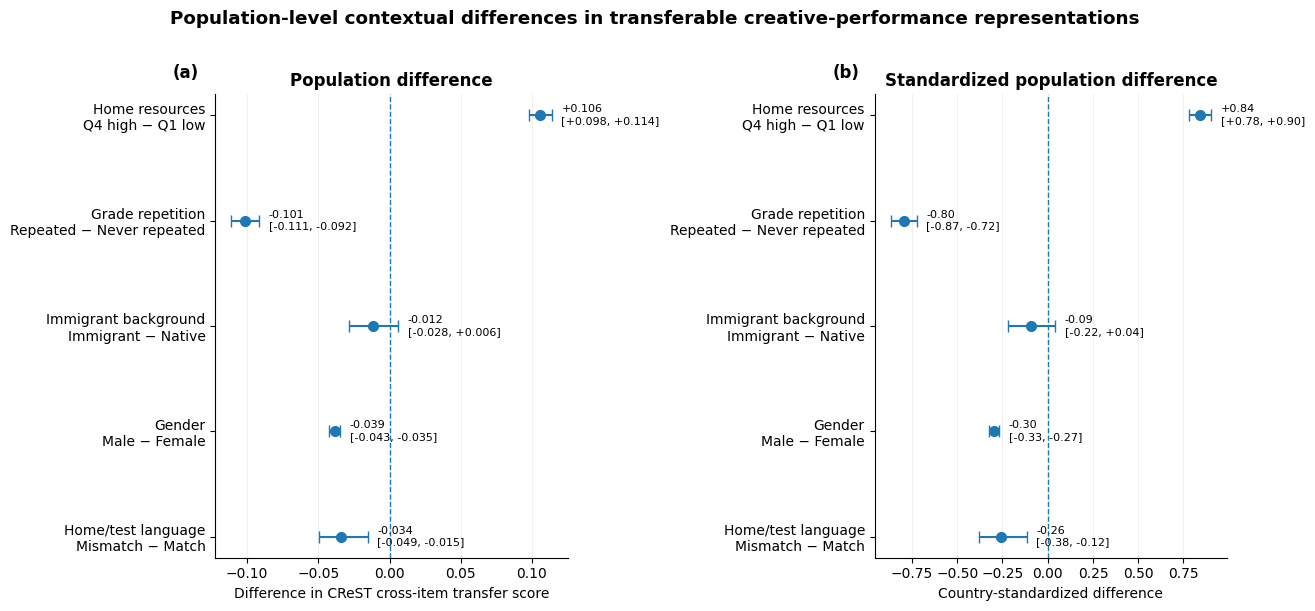

In [ ]:
# Main population-context figure

import matplotlib.pyplot as plt


plot_raw = (
    system_bootstrap_summary
    .copy()
)

plot_std = (
    standardized_summary
    .copy()
)


order = [
    "Home resources",
    "Grade repetition",
    "Immigrant background",
    "Gender",
    "Home/test language"
]


display_labels = {
    "Home resources":
        "Home resources\nQ4 high − Q1 low",

    "Grade repetition":
        "Grade repetition\nRepeated − Never repeated",

    "Immigrant background":
        "Immigrant background\nImmigrant − Native",

    "Gender":
        "Gender\nMale − Female",

    "Home/test language":
        "Home/test language\nMismatch − Match"
}


plot_raw = (
    plot_raw
    .set_index(
        "contrast"
    )
    .loc[
        order
    ]
    .reset_index()
)


plot_std = (
    plot_std
    .set_index(
        "contrast"
    )
    .loc[
        order
    ]
    .reset_index()
)


y = np.arange(
    len(
        order
    )
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        13.2,
        6.0
    )
)


# Panel A - Raw transfer-score differences

ax = axes[0]


x = (
    plot_raw[
        "estimate"
    ]
    .to_numpy()
)


xerr = np.vstack(
    [
        x
        -
        plot_raw[
            "system_boot_ci_low"
        ].to_numpy(),

        plot_raw[
            "system_boot_ci_high"
        ].to_numpy()
        -
        x
    ]
)


ax.errorbar(
    x,
    y,
    xerr=xerr,
    fmt="o",
    markersize=7,
    capsize=4,
    linewidth=1.5
)


ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)


ax.set_yticks(
    y
)

ax.set_yticklabels(
    [
        display_labels[
            c
        ]
        for c in order
    ]
)

ax.invert_yaxis()


ax.set_xlabel(
    "Difference in CReST cross-item transfer score"
)


ax.set_title(
    "Population difference",
    fontweight="semibold"
)


ax.grid(
    axis="x",
    alpha=0.18
)

ax.grid(
    axis="y",
    visible=False
)

ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)


for i, row in plot_raw.iterrows():

    ax.annotate(
        (
            f"{row['estimate']:+.3f}\n"
            f"[{row['system_boot_ci_low']:+.3f}, "
            f"{row['system_boot_ci_high']:+.3f}]"
        ),
        (
            row[
                "system_boot_ci_high"
            ],
            i
        ),
        xytext=(
            7,
            0
        ),
        textcoords="offset points",
        va="center",
        fontsize=8
    )


ax.text(
    -0.12,
    1.035,
    "(a)",
    transform=ax.transAxes,
    fontsize=12,
    fontweight="semibold"
)


# Panel B - Country-standardized differences

ax = axes[1]


x = (
    plot_std[
        "mean_standardized_difference"
    ]
    .to_numpy()
)


xerr = np.vstack(
    [
        x
        -
        plot_std[
            "system_boot_ci_low"
        ].to_numpy(),

        plot_std[
            "system_boot_ci_high"
        ].to_numpy()
        -
        x
    ]
)


ax.errorbar(
    x,
    y,
    xerr=xerr,
    fmt="o",
    markersize=7,
    capsize=4,
    linewidth=1.5
)


ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)


ax.set_yticks(
    y
)

ax.set_yticklabels(
    [
        display_labels[
            c
        ]
        for c in order
    ]
)

ax.invert_yaxis()


ax.set_xlabel(
    "Country-standardized difference"
)


ax.set_title(
    "Standardized population difference",
    fontweight="semibold"
)


ax.grid(
    axis="x",
    alpha=0.18
)

ax.grid(
    axis="y",
    visible=False
)

ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)


for i, row in plot_std.iterrows():

    ax.annotate(
        (
            f"{row['mean_standardized_difference']:+.2f}\n"
            f"[{row['system_boot_ci_low']:+.2f}, "
            f"{row['system_boot_ci_high']:+.2f}]"
        ),
        (
            row[
                "system_boot_ci_high"
            ],
            i
        ),
        xytext=(
            7,
            0
        ),
        textcoords="offset points",
        va="center",
        fontsize=8
    )


ax.text(
    -0.12,
    1.035,
    "(b)",
    transform=ax.transAxes,
    fontsize=12,
    fontweight="semibold"
)


fig.suptitle(
    "Population-level contextual differences in transferable "
    "creative-performance representations",
    fontsize=13.2,
    fontweight="semibold",
    y=1.01
)


fig.tight_layout()


fig.savefig(
    FIG_DIR
    / "crest_population_context_differences.pdf",
    bbox_inches="tight"
)


fig.savefig(
    FIG_DIR
    / "crest_population_context_differences.png",
    dpi=400,
    bbox_inches="tight"
)


plt.show()

In [ ]:
# Audit support for multivariable survey-weighted models

# Attach AGE

if "AGE" not in analysis_df.columns:

    age_lookup = pd.DataFrame(
        {
            "handoff_row_index":
                np.arange(
                    len(
                        model_context
                    ),
                    dtype=np.int64
                ),

            "AGE":
                pd.to_numeric(
                    model_context[
                        "AGE"
                    ],
                    errors="coerce"
                ).to_numpy()
        }
    )


    analysis_df = analysis_df.merge(

        age_lookup,

        on="handoff_row_index",

        how="left",

        validate="one_to_one"
    )


# Binary analysis variables

analysis_df[
    "male"
] = np.where(
    analysis_df[
        "ST004D01T"
    ].isna(),
    np.nan,
    (
        analysis_df[
            "ST004D01T"
        ]
        == 2.0
    ).astype(
        float
    )
)


analysis_df[
    "repeated_grade"
] = np.where(
    analysis_df[
        "REPEAT"
    ].isna(),
    np.nan,
    (
        analysis_df[
            "REPEAT"
        ]
        == 1.0
    ).astype(
        float
    )
)


analysis_df[
    "immigrant_background"
] = np.where(
    analysis_df[
        "IMMIG"
    ].isna(),
    np.nan,
    analysis_df[
        "IMMIG"
    ].isin(
        [
            2.0,
            3.0
        ]
    ).astype(
        float
    )
)


analysis_df[
    "language_mismatch"
] = np.where(
    analysis_df[
        "HOME_TEST_LANG_MATCH"
    ].isna(),
    np.nan,
    (
        analysis_df[
            "HOME_TEST_LANG_MATCH"
        ]
        == 0.0
    ).astype(
        float
    )
)


ADJUSTED_VARIABLES = [
    "crest_transfer_score",
    "HOMEPOS",
    "male",
    "repeated_grade",
    "immigrant_background",
    "language_mismatch",
    "AGE",
    "W_FSTUWT"
]


analysis_df[
    "adjusted_complete_case"
] = (
    analysis_df[
        ADJUSTED_VARIABLES
    ]
    .notna()
    .all(
        axis=1
    )
)


print(
    "Overall population-analysis N:",
    len(
        analysis_df
    )
)


print(
    "Complete-case N:",
    int(
        analysis_df[
            "adjusted_complete_case"
        ].sum()
    )
)


print(
    "Complete-case percentage:",
    (
        f"{100 * analysis_df['adjusted_complete_case'].mean():.2f}%"
    )
)


# System-level support

support_rows = []


for country, group in (
    analysis_df[
        analysis_df[
            "adjusted_complete_case"
        ]
    ]
    .groupby(
        "CNT"
    )
):

    support_rows.append(
        {
            "country":
                country,

            "n_complete":
                len(
                    group
                ),

            "female_n":
                int(
                    (
                        group[
                            "male"
                        ]
                        == 0
                    ).sum()
                ),

            "male_n":
                int(
                    (
                        group[
                            "male"
                        ]
                        == 1
                    ).sum()
                ),

            "never_repeat_n":
                int(
                    (
                        group[
                            "repeated_grade"
                        ]
                        == 0
                    ).sum()
                ),

            "repeat_n":
                int(
                    (
                        group[
                            "repeated_grade"
                        ]
                        == 1
                    ).sum()
                ),

            "native_n":
                int(
                    (
                        group[
                            "immigrant_background"
                        ]
                        == 0
                    ).sum()
                ),

            "immigrant_n":
                int(
                    (
                        group[
                            "immigrant_background"
                        ]
                        == 1
                    ).sum()
                ),

            "language_match_n":
                int(
                    (
                        group[
                            "language_mismatch"
                        ]
                        == 0
                    ).sum()
                ),

            "language_mismatch_n":
                int(
                    (
                        group[
                            "language_mismatch"
                        ]
                        == 1
                    ).sum()
                )
        }
    )


adjusted_support = pd.DataFrame(
    support_rows
)


print(
    "\nSYSTEM SUPPORT SUMMARY"
)

print(
    adjusted_support[
        [
            "n_complete",
            "female_n",
            "male_n",
            "repeat_n",
            "immigrant_n",
            "language_mismatch_n"
        ]
    ]
    .describe()
    .round(
        1
    )
    .to_string()
)


for threshold in [
    30,
    50,
    100
]:

    eligible = (

        (
            adjusted_support[
                "female_n"
            ]
            >= threshold
        )

        &

        (
            adjusted_support[
                "male_n"
            ]
            >= threshold
        )

        &

        (
            adjusted_support[
                "never_repeat_n"
            ]
            >= threshold
        )

        &

        (
            adjusted_support[
                "repeat_n"
            ]
            >= threshold
        )

        &

        (
            adjusted_support[
                "native_n"
            ]
            >= threshold
        )

        &

        (
            adjusted_support[
                "immigrant_n"
            ]
            >= threshold
        )

        &

        (
            adjusted_support[
                "language_match_n"
            ]
            >= threshold
        )

        &

        (
            adjusted_support[
                "language_mismatch_n"
            ]
            >= threshold
        )
    )


    print(
        f"\nSystems with >= {threshold} students "
        f"in every binary subgroup:",
        int(
            eligible.sum()
        )
    )


adjusted_support.to_csv(

    POP_DIR
    / "crest_adjusted_model_support_audit.csv",

    index=False
)

Overall population-analysis N: 140839
Complete-case N: 131221
Complete-case percentage: 93.17%

SYSTEM SUPPORT SUMMARY
       n_complete  female_n  male_n  repeat_n  immigrant_n  language_mismatch_n
count        63.0      63.0    63.0      63.0         63.0                 63.0
mean       2082.9    1059.7  1023.2     199.5        259.9                379.0
std        1309.5     657.5   655.0     239.6        513.4                611.9
min         805.0     412.0   358.0       7.0          6.0                  6.0
25%        1537.5     760.0   756.5      49.0         24.0                 69.5
50%        1748.0     888.0   856.0     119.0         78.0                145.0
75%        1998.5    1038.0   962.0     270.0        282.5                356.5
max        8259.0    4090.0  4169.0    1471.0       3494.0               3681.0

Systems with >= 30 students in every binary subgroup: 33

Systems with >= 50 students in every binary subgroup: 26

Systems with >= 100 students in every binary

In [ ]:
# Survey-weighted within-system adjusted regression

ADJUSTED_PREDICTORS = [
    "HOMEPOS_z",
    "male",
    "repeated_grade",
    "immigrant_background",
    "language_mismatch",
    "AGE_z"
]

COEFFICIENT_NAMES = [
    "Intercept",
    "HOMEPOS",
    "Male",
    "Repeated grade",
    "Immigrant background",
    "Language mismatch",
    "Age"
]


def weighted_mean_sd(values, weights):

    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    valid = (
        np.isfinite(values)
        &
        np.isfinite(weights)
        &
        (weights > 0)
    )

    values = values[valid]
    weights = weights[valid]

    mean = np.sum(
        weights * values
    ) / np.sum(weights)

    variance = np.sum(
        weights * (values - mean) ** 2
    ) / np.sum(weights)

    sd = np.sqrt(variance)

    return float(mean), float(sd)


def weighted_standardize(values, weights):

    mean, sd = weighted_mean_sd(
        values,
        weights
    )

    if (
        not np.isfinite(sd)
        or sd <= 0
    ):
        raise ValueError(
            "Non-positive weighted SD."
        )

    return (
        np.asarray(values, dtype=float)
        - mean
    ) / sd


def fit_weighted_standardized_model(
    df,
    weight_col
):

    temp = df.copy()

    w = temp[
        weight_col
    ].to_numpy(
        dtype=float
    )

    # Recompute standardization under the current
    # main/replicate weight.
    y = weighted_standardize(
        temp[
            "crest_transfer_score"
        ].to_numpy(dtype=float),
        w
    )

    home_z = weighted_standardize(
        temp[
            "HOMEPOS"
        ].to_numpy(dtype=float),
        w
    )

    age_z = weighted_standardize(
        temp[
            "AGE"
        ].to_numpy(dtype=float),
        w
    )

    X = np.column_stack(
        [
            np.ones(
                len(temp),
                dtype=float
            ),

            home_z,

            temp[
                "male"
            ].to_numpy(dtype=float),

            temp[
                "repeated_grade"
            ].to_numpy(dtype=float),

            temp[
                "immigrant_background"
            ].to_numpy(dtype=float),

            temp[
                "language_mismatch"
            ].to_numpy(dtype=float),

            age_z
        ]
    )

    sqrt_w = np.sqrt(w)

    Xw = (
        X
        *
        sqrt_w[:, None]
    )

    yw = (
        y
        *
        sqrt_w
    )

    beta, _, rank, singular_values = (
        np.linalg.lstsq(
            Xw,
            yw,
            rcond=None
        )
    )

    condition_number = (
        np.inf
        if singular_values[-1] == 0
        else float(
            singular_values[0]
            /
            singular_values[-1]
        )
    )

    return (
        beta.astype(float),
        int(rank),
        condition_number
    )


def brr_fay_adjusted_model(df):

    beta_main, rank, cond = (
        fit_weighted_standardized_model(
            df,
            "W_FSTUWT"
        )
    )

    beta_rep = []

    for weight_col in replicate_cols:

        beta_r, _, _ = (
            fit_weighted_standardized_model(
                df,
                weight_col
            )
        )

        beta_rep.append(
            beta_r
        )

    beta_rep = np.asarray(
        beta_rep,
        dtype=float
    )

    variance = (
        BRR_FAY_FACTOR
        *
        np.sum(
            (
                beta_rep
                -
                beta_main[None, :]
            ) ** 2,
            axis=0
        )
    )

    se = np.sqrt(
        variance
    )

    return {
        "beta":
            beta_main,

        "se":
            se,

        "variance":
            variance,

        "ci_low":
            beta_main
            -
            1.96 * se,

        "ci_high":
            beta_main
            +
            1.96 * se,

        "rank":
            rank,

        "condition_number":
            cond
    }


print(
    "Adjusted survey-weighted model functions ready."
)

Adjusted survey-weighted model functions ready.


In [ ]:
# Primary multivariable analysis
# Require >=30 complete-case students in every binary subgroup

PRIMARY_MIN_SUBGROUP = 30


eligible30 = (

    (adjusted_support["female_n"] >= PRIMARY_MIN_SUBGROUP)
    &
    (adjusted_support["male_n"] >= PRIMARY_MIN_SUBGROUP)

    &
    (adjusted_support["never_repeat_n"] >= PRIMARY_MIN_SUBGROUP)
    &
    (adjusted_support["repeat_n"] >= PRIMARY_MIN_SUBGROUP)

    &
    (adjusted_support["native_n"] >= PRIMARY_MIN_SUBGROUP)
    &
    (adjusted_support["immigrant_n"] >= PRIMARY_MIN_SUBGROUP)

    &
    (adjusted_support["language_match_n"] >= PRIMARY_MIN_SUBGROUP)
    &
    (adjusted_support["language_mismatch_n"] >= PRIMARY_MIN_SUBGROUP)
)


eligible_systems_30 = (
    adjusted_support.loc[
        eligible30,
        "country"
    ]
    .tolist()
)


print(
    "Primary eligible systems:",
    len(
        eligible_systems_30
    )
)


adjusted_rows = []


for country in eligible_systems_30:

    country_df = (

        analysis_df[
            (
                analysis_df["CNT"] == country
            )
            &
            (
                analysis_df[
                    "adjusted_complete_case"
                ]
            )
        ]
        .copy()
    )


    result = (
        brr_fay_adjusted_model(
            country_df
        )
    )


    assert (
        result["rank"]
        == len(
            COEFFICIENT_NAMES
        )
    )


    for j, coefficient in enumerate(
        COEFFICIENT_NAMES
    ):

        adjusted_rows.append(
            {
                "country":
                    country,

                "coefficient":
                    coefficient,

                "n_complete":
                    len(
                        country_df
                    ),

                "estimate":
                    float(
                        result[
                            "beta"
                        ][j]
                    ),

                "se":
                    float(
                        result[
                            "se"
                        ][j]
                    ),

                "variance":
                    float(
                        result[
                            "variance"
                        ][j]
                    ),

                "ci_low":
                    float(
                        result[
                            "ci_low"
                        ][j]
                    ),

                "ci_high":
                    float(
                        result[
                            "ci_high"
                        ][j]
                    ),

                "condition_number":
                    float(
                        result[
                            "condition_number"
                        ]
                    )
            }
        )


adjusted_country_df = pd.DataFrame(
    adjusted_rows
)


adjusted_country_df.to_csv(

    POP_DIR
    / "crest_adjusted_associations_by_system_min30.csv",

    index=False
)


print(
    "\nCondition-number audit:"
)

condition_audit = (

    adjusted_country_df[
        [
            "country",
            "condition_number"
        ]
    ]
    .drop_duplicates()
)


print(
    condition_audit[
        "condition_number"
    ]
    .describe()
    .to_string()
)


print(
    "\nPrimary adjusted models complete."
)

Primary eligible systems: 33

Condition-number audit:
count    33.000000
mean      6.297323
std       1.584577
min       4.095174
25%       4.869344
50%       6.225079
75%       7.438465
max       9.436307

Primary adjusted models complete.


In [ ]:
# Equal-system adjusted associations + system bootstrap

ADJUSTED_BOOT_SEED = 20261012
N_ADJUSTED_BOOT = 10000

rng_adjusted = np.random.default_rng(
    ADJUSTED_BOOT_SEED
)


adjusted_summary_rows = []


for coefficient in [
    "HOMEPOS",
    "Male",
    "Repeated grade",
    "Immigrant background",
    "Language mismatch",
    "Age"
]:

    temp = (
        adjusted_country_df[
            adjusted_country_df[
                "coefficient"
            ]
            == coefficient
        ]
        .copy()
    )


    effects = temp[
        "estimate"
    ].to_numpy(
        dtype=float
    )


    K = len(
        effects
    )


    mean_effect = float(
        effects.mean()
    )


    # Design-based variance conditional on observed systems

    design_variance = float(
        temp[
            "variance"
        ].sum()
        /
        (K ** 2)
    )

    design_se = float(
        np.sqrt(
            design_variance
        )
    )


    # System bootstrap

    boot = np.empty(
        N_ADJUSTED_BOOT,
        dtype=float
    )


    for b in range(
        N_ADJUSTED_BOOT
    ):

        idx = rng_adjusted.integers(
            0,
            K,
            size=K
        )

        boot[b] = (
            effects[
                idx
            ].mean()
        )


    adjusted_summary_rows.append(
        {
            "coefficient":
                coefficient,

            "n_systems":
                K,

            "mean_adjusted_association":
                mean_effect,

            "median_adjusted_association":
                float(
                    np.median(
                        effects
                    )
                ),

            "between_system_sd":
                float(
                    effects.std(
                        ddof=1
                    )
                ),

            "design_se":
                design_se,

            "design_ci_low":
                float(
                    mean_effect
                    -
                    1.96 * design_se
                ),

            "design_ci_high":
                float(
                    mean_effect
                    +
                    1.96 * design_se
                ),

            "system_boot_ci_low":
                float(
                    np.quantile(
                        boot,
                        0.025
                    )
                ),

            "system_boot_ci_high":
                float(
                    np.quantile(
                        boot,
                        0.975
                    )
                ),

            "pct_positive_systems":
                float(
                    100
                    *
                    np.mean(
                        effects > 0
                    )
                )
        }
    )


adjusted_summary_30 = pd.DataFrame(
    adjusted_summary_rows
)


adjusted_summary_30.to_csv(

    POP_DIR
    / "crest_adjusted_associations_summary_min30.csv",

    index=False
)


print(
    adjusted_summary_30.to_string(
        index=False
    )
)

         coefficient  n_systems  mean_adjusted_association  median_adjusted_association  between_system_sd  design_se  design_ci_low  design_ci_high  system_boot_ci_low  system_boot_ci_high  pct_positive_systems
             HOMEPOS         33                   0.260477                     0.237600           0.072190   0.004451       0.251753        0.269202            0.236427             0.285028            100.000000
                Male         33                  -0.273496                    -0.255868           0.112752   0.007994      -0.289164       -0.257829           -0.313518            -0.237169              0.000000
      Repeated grade         33                  -0.588417                    -0.616803           0.187077   0.018608      -0.624889       -0.551945           -0.652257            -0.527676              0.000000
Immigrant background         33                   0.097839                     0.072737           0.279766   0.018319       0.061933        0.133745    

In [ ]:
# Sensitivity analysis with >=50 students
# in every binary subgroup

SENSITIVITY_MIN_SUBGROUP = 50


eligible50 = (

    (adjusted_support["female_n"] >= SENSITIVITY_MIN_SUBGROUP)
    &
    (adjusted_support["male_n"] >= SENSITIVITY_MIN_SUBGROUP)

    &
    (adjusted_support["never_repeat_n"] >= SENSITIVITY_MIN_SUBGROUP)
    &
    (adjusted_support["repeat_n"] >= SENSITIVITY_MIN_SUBGROUP)

    &
    (adjusted_support["native_n"] >= SENSITIVITY_MIN_SUBGROUP)
    &
    (adjusted_support["immigrant_n"] >= SENSITIVITY_MIN_SUBGROUP)

    &
    (adjusted_support["language_match_n"] >= SENSITIVITY_MIN_SUBGROUP)
    &
    (adjusted_support["language_mismatch_n"] >= SENSITIVITY_MIN_SUBGROUP)
)


eligible_systems_50 = (
    adjusted_support.loc[
        eligible50,
        "country"
    ]
    .tolist()
)


print(
    "Sensitivity eligible systems:",
    len(
        eligible_systems_50
    )
)


# Fit system-specific models

adjusted_rows_50 = []


for country in eligible_systems_50:

    country_df = (

        analysis_df[
            (
                analysis_df["CNT"] == country
            )
            &
            (
                analysis_df[
                    "adjusted_complete_case"
                ]
            )
        ]
        .copy()
    )


    result = (
        brr_fay_adjusted_model(
            country_df
        )
    )


    assert (
        result["rank"]
        == len(
            COEFFICIENT_NAMES
        )
    )


    for j, coefficient in enumerate(
        COEFFICIENT_NAMES
    ):

        adjusted_rows_50.append(
            {
                "country":
                    country,

                "coefficient":
                    coefficient,

                "n_complete":
                    len(
                        country_df
                    ),

                "estimate":
                    float(
                        result[
                            "beta"
                        ][j]
                    ),

                "se":
                    float(
                        result[
                            "se"
                        ][j]
                    ),

                "variance":
                    float(
                        result[
                            "variance"
                        ][j]
                    ),

                "ci_low":
                    float(
                        result[
                            "ci_low"
                        ][j]
                    ),

                "ci_high":
                    float(
                        result[
                            "ci_high"
                        ][j]
                    ),

                "condition_number":
                    float(
                        result[
                            "condition_number"
                        ]
                    )
            }
        )


adjusted_country_50 = pd.DataFrame(
    adjusted_rows_50
)


adjusted_country_50.to_csv(

    POP_DIR
    / "crest_adjusted_associations_by_system_min50.csv",

    index=False
)


# Equal-system aggregate + system bootstrap

rng50 = np.random.default_rng(
    20261013
)


summary_rows_50 = []


for coefficient in [
    "HOMEPOS",
    "Male",
    "Repeated grade",
    "Immigrant background",
    "Language mismatch",
    "Age"
]:

    temp = (
        adjusted_country_50[
            adjusted_country_50[
                "coefficient"
            ]
            == coefficient
        ]
    )


    effects = (
        temp[
            "estimate"
        ]
        .to_numpy(
            dtype=float
        )
    )


    K = len(
        effects
    )


    mean_effect = float(
        effects.mean()
    )


    design_variance = float(
        temp[
            "variance"
        ].sum()
        /
        (K ** 2)
    )


    design_se = float(
        np.sqrt(
            design_variance
        )
    )


    boot = np.empty(
        N_ADJUSTED_BOOT,
        dtype=float
    )


    for b in range(
        N_ADJUSTED_BOOT
    ):

        idx = rng50.integers(
            0,
            K,
            size=K
        )


        boot[b] = (
            effects[
                idx
            ].mean()
        )


    summary_rows_50.append(
        {
            "coefficient":
                coefficient,

            "n_systems":
                K,

            "mean_adjusted_association":
                mean_effect,

            "median_adjusted_association":
                float(
                    np.median(
                        effects
                    )
                ),

            "between_system_sd":
                float(
                    effects.std(
                        ddof=1
                    )
                ),

            "design_se":
                design_se,

            "design_ci_low":
                float(
                    mean_effect
                    -
                    1.96 * design_se
                ),

            "design_ci_high":
                float(
                    mean_effect
                    +
                    1.96 * design_se
                ),

            "system_boot_ci_low":
                float(
                    np.quantile(
                        boot,
                        0.025
                    )
                ),

            "system_boot_ci_high":
                float(
                    np.quantile(
                        boot,
                        0.975
                    )
                ),

            "pct_positive_systems":
                float(
                    100
                    *
                    np.mean(
                        effects > 0
                    )
                )
        }
    )


adjusted_summary_50 = pd.DataFrame(
    summary_rows_50
)


adjusted_summary_50.to_csv(

    POP_DIR
    / "crest_adjusted_associations_summary_min50.csv",

    index=False
)


print(
    adjusted_summary_50.to_string(
        index=False
    )
)

Sensitivity eligible systems: 26
         coefficient  n_systems  mean_adjusted_association  median_adjusted_association  between_system_sd  design_se  design_ci_low  design_ci_high  system_boot_ci_low  system_boot_ci_high  pct_positive_systems
             HOMEPOS         26                   0.239899                     0.231084           0.058417   0.004979       0.230140        0.249658            0.218823             0.262293            100.000000
                Male         26                  -0.273471                    -0.252484           0.108958   0.008837      -0.290792       -0.256150           -0.316062            -0.232928              0.000000
      Repeated grade         26                  -0.578567                    -0.564634           0.194298   0.019285      -0.616366       -0.540768           -0.651820            -0.507030              0.000000
Immigrant background         26                   0.129274                     0.122596           0.290878   0.016850  

In [ ]:
# Compare primary (>=30) and sensitivity (>=50)

comparison = (

    adjusted_summary_30[
        [
            "coefficient",
            "n_systems",
            "mean_adjusted_association",
            "system_boot_ci_low",
            "system_boot_ci_high"
        ]
    ]

    .rename(
        columns={
            "n_systems":
                "n_systems_min30",

            "mean_adjusted_association":
                "estimate_min30",

            "system_boot_ci_low":
                "ci_low_min30",

            "system_boot_ci_high":
                "ci_high_min30"
        }
    )

    .merge(

        adjusted_summary_50[
            [
                "coefficient",
                "n_systems",
                "mean_adjusted_association",
                "system_boot_ci_low",
                "system_boot_ci_high"
            ]
        ]

        .rename(
            columns={
                "n_systems":
                    "n_systems_min50",

                "mean_adjusted_association":
                    "estimate_min50",

                "system_boot_ci_low":
                    "ci_low_min50",

                "system_boot_ci_high":
                    "ci_high_min50"
            }
        ),

        on="coefficient",

        how="inner"
    )
)


comparison[
    "estimate_change_min50_minus_min30"
] = (

    comparison[
        "estimate_min50"
    ]

    -

    comparison[
        "estimate_min30"
    ]
)


comparison.to_csv(

    POP_DIR
    / "crest_adjusted_min30_vs_min50.csv",

    index=False
)


print(
    comparison.to_string(
        index=False
    )
)

         coefficient  n_systems_min30  estimate_min30  ci_low_min30  ci_high_min30  n_systems_min50  estimate_min50  ci_low_min50  ci_high_min50  estimate_change_min50_minus_min30
             HOMEPOS               33        0.260477      0.236427       0.285028               26        0.239899      0.218823       0.262293                          -0.020578
                Male               33       -0.273496     -0.313518      -0.237169               26       -0.273471     -0.316062      -0.232928                           0.000025
      Repeated grade               33       -0.588417     -0.652257      -0.527676               26       -0.578567     -0.651820      -0.507030                           0.009851
Immigrant background               33        0.097839      0.005756       0.195777               26        0.129274      0.026278       0.242172                           0.031435
   Language mismatch               33       -0.102995     -0.208877       0.035164               26 

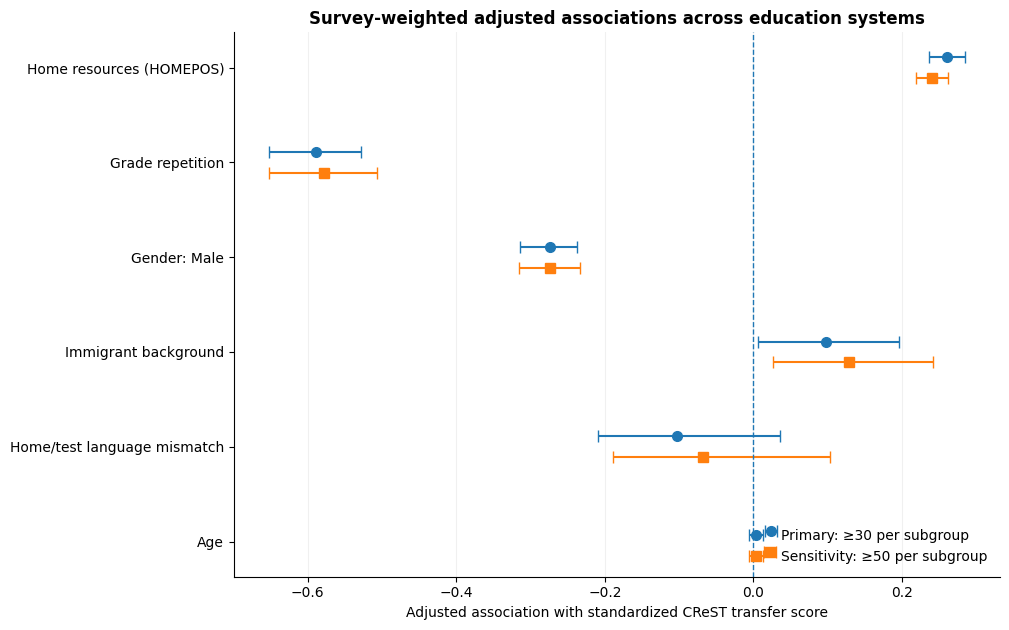

In [ ]:
# Primary vs sensitivity adjusted associations figure

import matplotlib.pyplot as plt


plot_order = [
    "HOMEPOS",
    "Repeated grade",
    "Male",
    "Immigrant background",
    "Language mismatch",
    "Age"
]


display_names = {
    "HOMEPOS":
        "Home resources (HOMEPOS)",

    "Repeated grade":
        "Grade repetition",

    "Male":
        "Gender: Male",

    "Immigrant background":
        "Immigrant background",

    "Language mismatch":
        "Home/test language mismatch",

    "Age":
        "Age"
}


plot_df = (
    comparison
    .set_index(
        "coefficient"
    )
    .loc[
        plot_order
    ]
    .reset_index()
)


y = np.arange(
    len(
        plot_df
    )
)


fig, ax = plt.subplots(
    figsize=(
        10.2,
        6.4
    )
)


offset = 0.11


# Primary >=30

x30 = (
    plot_df[
        "estimate_min30"
    ].to_numpy()
)


err30 = np.vstack(
    [
        x30
        -
        plot_df[
            "ci_low_min30"
        ].to_numpy(),

        plot_df[
            "ci_high_min30"
        ].to_numpy()
        -
        x30
    ]
)


ax.errorbar(
    x30,
    y - offset,
    xerr=err30,
    fmt="o",
    markersize=7,
    capsize=4,
    linewidth=1.5,
    label="Primary: ≥30 per subgroup"
)


# Sensitivity >=50

x50 = (
    plot_df[
        "estimate_min50"
    ].to_numpy()
)


err50 = np.vstack(
    [
        x50
        -
        plot_df[
            "ci_low_min50"
        ].to_numpy(),

        plot_df[
            "ci_high_min50"
        ].to_numpy()
        -
        x50
    ]
)


ax.errorbar(
    x50,
    y + offset,
    xerr=err50,
    fmt="s",
    markersize=6.5,
    capsize=4,
    linewidth=1.5,
    label="Sensitivity: ≥50 per subgroup"
)


ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)


ax.set_yticks(
    y
)


ax.set_yticklabels(
    [
        display_names[
            c
        ]
        for c in plot_order
    ]
)


ax.invert_yaxis()


ax.set_xlabel(
    "Adjusted association with standardized CReST transfer score"
)


ax.set_ylabel(
    ""
)


ax.set_title(
    "Survey-weighted adjusted associations across education systems",
    fontweight="semibold"
)


ax.grid(
    axis="x",
    alpha=0.18
)

ax.grid(
    axis="y",
    visible=False
)


ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)


ax.legend(
    frameon=False,
    loc="lower right"
)


fig.tight_layout()


fig.savefig(
    FIG_DIR
    / "crest_adjusted_population_associations.pdf",
    bbox_inches="tight"
)


fig.savefig(
    FIG_DIR
    / "crest_adjusted_population_associations.png",
    dpi=400,
    bbox_inches="tight"
)


plt.show()

In [ ]:
# Locked summary of population-level adjusted findings

final_population_rows = []


interpretation_map = {

    "HOMEPOS":
        "Robust positive association",

    "Male":
        "Robust negative association",

    "Repeated grade":
        "Robust negative association",

    "Immigrant background":
        "Positive conditional association; heterogeneous across systems",

    "Language mismatch":
        "No robust cross-system adjusted association",

    "Age":
        "Small robust positive association"
}


for _, row in comparison.iterrows():

    robust_same_direction = (

        (
            row[
                "ci_low_min30"
            ] > 0
            and
            row[
                "ci_low_min50"
            ] > 0
        )

        or

        (
            row[
                "ci_high_min30"
            ] < 0
            and
            row[
                "ci_high_min50"
            ] < 0
        )
    )


    final_population_rows.append(
        {
            "coefficient":
                row[
                    "coefficient"
                ],

            "primary_n_systems":
                int(
                    row[
                        "n_systems_min30"
                    ]
                ),

            "primary_estimate":
                float(
                    row[
                        "estimate_min30"
                    ]
                ),

            "primary_ci_low":
                float(
                    row[
                        "ci_low_min30"
                    ]
                ),

            "primary_ci_high":
                float(
                    row[
                        "ci_high_min30"
                    ]
                ),

            "sensitivity_n_systems":
                int(
                    row[
                        "n_systems_min50"
                    ]
                ),

            "sensitivity_estimate":
                float(
                    row[
                        "estimate_min50"
                    ]
                ),

            "sensitivity_ci_low":
                float(
                    row[
                        "ci_low_min50"
                    ]
                ),

            "sensitivity_ci_high":
                float(
                    row[
                        "ci_high_min50"
                    ]
                ),

            "same_direction_supported_both":
                bool(
                    robust_same_direction
                ),

            "interpretation":
                interpretation_map[
                    row[
                        "coefficient"
                    ]
                ]
        }
    )


final_population_summary = pd.DataFrame(
    final_population_rows
)


final_population_summary.to_csv(

    POP_DIR
    / "crest_population_adjusted_findings_LOCKED.csv",

    index=False
)


print(
    final_population_summary.to_string(
        index=False
    )
)

         coefficient  primary_n_systems  primary_estimate  primary_ci_low  primary_ci_high  sensitivity_n_systems  sensitivity_estimate  sensitivity_ci_low  sensitivity_ci_high  same_direction_supported_both                                                 interpretation
             HOMEPOS                 33          0.260477        0.236427         0.285028                     26              0.239899            0.218823             0.262293                           True                                    Robust positive association
                Male                 33         -0.273496       -0.313518        -0.237169                     26             -0.273471           -0.316062            -0.232928                           True                                    Robust negative association
      Repeated grade                 33         -0.588417       -0.652257        -0.527676                     26             -0.578567           -0.651820            -0.507030           

In [ ]:
# Discover and load official PISA 2022 Creative Thinking PVs
# Robust version: automatically locate the correct SAV file

import pyreadstat


RAW_DIR = (
    BASE_DIR
    / "raw"
)


CREATIVE_PV_COLS = [
    f"PV{i}CRTH_NC"
    for i in range(
        1,
        11
    )
]


# 1. Discover which SAV file actually contains the PVs
#    Metadata only -- no full dataset loading.

sav_files = sorted(
    RAW_DIR.glob(
        "*.SAV"
    )
)


print(
    "SAV files found:",
    len(
        sav_files
    )
)


discovery_rows = []


for sav_file in sav_files:

    try:

        _, meta = pyreadstat.read_sav(
            str(
                sav_file
            ),
            metadataonly=True
        )


        columns = set(
            meta.column_names
        )


        found_pvs = [
            pv
            for pv in CREATIVE_PV_COLS
            if pv in columns
        ]


        crth_like = [
            c
            for c in meta.column_names
            if "CRTH" in c.upper()
        ]


        discovery_rows.append(
            {
                "file":
                    sav_file.name,

                "n_columns":
                    len(
                        meta.column_names
                    ),

                "n_requested_pvs":
                    len(
                        found_pvs
                    ),

                "requested_pvs":
                    found_pvs,

                "crth_like_count":
                    len(
                        crth_like
                    ),

                "crth_like_first20":
                    crth_like[:20]
            }
        )


    except Exception as e:

        discovery_rows.append(
            {
                "file":
                    sav_file.name,

                "n_columns":
                    np.nan,

                "n_requested_pvs":
                    -1,

                "requested_pvs":
                    [],

                "crth_like_count":
                    np.nan,

                "crth_like_first20":
                    [
                        f"ERROR: {e}"
                    ]
            }
        )


discovery_df = pd.DataFrame(
    discovery_rows
)


print(
    "\nCREATIVE-THINKING PV DISCOVERY"
)

print(
    "=" * 80
)


for _, row in discovery_df.iterrows():

    print(
        f"\n{row['file']}"
    )

    print(
        "  columns:",
        row[
            "n_columns"
        ]
    )

    print(
        "  requested PVs found:",
        row[
            "n_requested_pvs"
        ]
    )

    if (
        row[
            "n_requested_pvs"
        ] > 0
    ):

        print(
            "  PVs:",
            row[
                "requested_pvs"
            ]
        )

    if (
        row[
            "crth_like_count"
        ] > 0
    ):

        print(
            "  CRTH-like columns:",
            row[
                "crth_like_first20"
            ]
        )


# 2. Identify file containing ALL 10 Creative Thinking PVs

full_matches = discovery_df[
    discovery_df[
        "n_requested_pvs"
    ]
    == len(
        CREATIVE_PV_COLS
    )
]


assert len(
    full_matches
) >= 1, (
    "No SAV file contains all 10 requested "
    "PV1CRTH_NC–PV10CRTH_NC columns. "
    "Inspect the discovery output above."
)


if len(
    full_matches
) > 1:

    print(
        "\nWARNING: More than one file contains all 10 PVs:"
    )

    print(
        full_matches[
            "file"
        ].tolist()
    )


PV_SOURCE_FILE = (
    RAW_DIR
    / full_matches.iloc[0][
        "file"
    ]
)


print(
    "\nSelected PV source:",
    PV_SOURCE_FILE.name
)


# 3. Load only ID + 10 PV columns

pv_usecols = [
    "CNT",
    "CNTSTUID"
] + CREATIVE_PV_COLS


creative_pv_df, creative_pv_meta = (
    pyreadstat.read_sav(
        str(
            PV_SOURCE_FILE
        ),
        usecols=pv_usecols
    )
)


print(
    "\nColumns actually loaded:"
)

print(
    creative_pv_df.columns.tolist()
)


assert set(
    CREATIVE_PV_COLS
).issubset(
    creative_pv_df.columns
), (
    "PV source was identified, but the requested "
    "columns were not loaded correctly."
)


# 4. Harmonize keys

creative_pv_df[
    "CNT"
] = (
    creative_pv_df[
        "CNT"
    ]
    .astype(
        str
    )
)


creative_pv_df[
    "CNTSTUID"
] = (
    pd.to_numeric(
        creative_pv_df[
            "CNTSTUID"
        ],
        errors="raise"
    )
    .astype(
        np.int64
    )
)


analysis_df[
    "CNT"
] = (
    analysis_df[
        "CNT"
    ]
    .astype(
        str
    )
)


analysis_df[
    "CNTSTUID"
] = (
    pd.to_numeric(
        analysis_df[
            "CNTSTUID"
        ],
        errors="raise"
    )
    .astype(
        np.int64
    )
)


# 5. Ensure unique merge key

duplicate_keys = (
    creative_pv_df[
        [
            "CNT",
            "CNTSTUID"
        ]
    ]
    .duplicated()
)


assert not duplicate_keys.any(), (
    "Duplicate CNT + CNTSTUID keys found "
    "in the PV source."
)


# 6. Safe merge

# Remove any PV-like columns if cell is rerun.
existing_pv_like = [
    c
    for c in analysis_df.columns
    if any(
        c == pv
        or
        c.startswith(
            f"{pv}_"
        )
        for pv in CREATIVE_PV_COLS
    )
]


analysis_base_df = (
    analysis_df
    .drop(
        columns=existing_pv_like,
        errors="ignore"
    )
    .copy()
)


analysis_pv_df = (
    analysis_base_df
    .merge(

        creative_pv_df,

        on=[
            "CNT",
            "CNTSTUID"
        ],

        how="left",

        validate="one_to_one"
    )
)


# 7. Coverage audit

pv_complete = (
    analysis_pv_df[
        CREATIVE_PV_COLS
    ]
    .notna()
    .all(
        axis=1
    )
)


print(
    "\nPISA CREATIVE THINKING PV COVERAGE"
)

print(
    "=" * 60
)

print(
    "PV source file:",
    PV_SOURCE_FILE.name
)

print(
    "Population-analysis students:",
    len(
        analysis_pv_df
    )
)

print(
    "All 10 PVs available:",
    int(
        pv_complete.sum()
    )
)

print(
    "Complete percentage:",
    f"{100 * pv_complete.mean():.3f}%"
)

print(
    "Systems with PV-complete students:",
    analysis_pv_df.loc[
        pv_complete,
        "CNT"
    ].nunique()
)


print(
    "\nMissingness by PV:"
)

print(
    analysis_pv_df[
        CREATIVE_PV_COLS
    ]
    .isna()
    .mean()
    .mul(
        100
    )
    .round(
        4
    )
    .to_string()
)


# DO NOT average PV1-PV10 at student level.

analysis_pv_df.to_pickle(
    POP_DIR
    / "crest_population_with_creative_pvs.pkl"
)


discovery_df.to_pickle(
    POP_DIR
    / "crest_creative_pv_file_discovery.pkl"
)


print(
    "\nCreative Thinking PV discovery + merge: PASS"
)

SAV files found: 5

CREATIVE-THINKING PV DISCOVERY

CY08MSP_CRT_COG.SAV
  columns: 301
  requested PVs found: 10
  PVs: ['PV1CRTH_NC', 'PV2CRTH_NC', 'PV3CRTH_NC', 'PV4CRTH_NC', 'PV5CRTH_NC', 'PV6CRTH_NC', 'PV7CRTH_NC', 'PV8CRTH_NC', 'PV9CRTH_NC', 'PV10CRTH_NC']
  CRTH-like columns: ['PV1CRTH_NC', 'PV2CRTH_NC', 'PV3CRTH_NC', 'PV4CRTH_NC', 'PV5CRTH_NC', 'PV6CRTH_NC', 'PV7CRTH_NC', 'PV8CRTH_NC', 'PV9CRTH_NC', 'PV10CRTH_NC']

CY08MSP_SCH_QQQ.SAV
  columns: 431
  requested PVs found: 0

CY08MSP_STU_COG.SAV
  columns: 5023
  requested PVs found: 0

CY08MSP_STU_QQQ.SAV
  columns: 1278
  requested PVs found: 0

CY08MSP_STU_TIM.SAV
  columns: 172
  requested PVs found: 0

Selected PV source: CY08MSP_CRT_COG.SAV

Columns actually loaded:
['CNT', 'CNTSTUID', 'PV1CRTH_NC', 'PV2CRTH_NC', 'PV3CRTH_NC', 'PV4CRTH_NC', 'PV5CRTH_NC', 'PV6CRTH_NC', 'PV7CRTH_NC', 'PV8CRTH_NC', 'PV9CRTH_NC', 'PV10CRTH_NC']

PISA CREATIVE THINKING PV COVERAGE
PV source file: CY08MSP_CRT_COG.SAV
Population-analysis students:

In [ ]:
# PISA plausible-value + BRR-Fay correlation estimator

N_PV = len(
    CREATIVE_PV_COLS
)

assert N_PV == 10


def weighted_pearson(
    x,
    y,
    w
):

    x = np.asarray(
        x,
        dtype=float
    )

    y = np.asarray(
        y,
        dtype=float
    )

    w = np.asarray(
        w,
        dtype=float
    )


    valid = (
        np.isfinite(x)
        &
        np.isfinite(y)
        &
        np.isfinite(w)
        &
        (w > 0)
    )


    x = x[
        valid
    ]

    y = y[
        valid
    ]

    w = w[
        valid
    ]


    if len(
        x
    ) < 3:

        return np.nan


    w_sum = np.sum(
        w
    )


    mx = np.sum(
        w * x
    ) / w_sum


    my = np.sum(
        w * y
    ) / w_sum


    dx = (
        x - mx
    )

    dy = (
        y - my
    )


    cov_xy = (
        np.sum(
            w
            *
            dx
            *
            dy
        )
        /
        w_sum
    )


    var_x = (
        np.sum(
            w
            *
            dx ** 2
        )
        /
        w_sum
    )


    var_y = (
        np.sum(
            w
            *
            dy ** 2
        )
        /
        w_sum
    )


    if (
        var_x <= 0
        or
        var_y <= 0
    ):

        return np.nan


    return float(
        cov_xy
        /
        np.sqrt(
            var_x
            *
            var_y
        )
    )


def pisa_pv_brr_correlation(
    df,
    x_col,
    pv_cols
):

    theta_pv = []
    sampling_variance_pv = []


    x = (
        df[
            x_col
        ]
        .to_numpy(
            dtype=float
        )
    )


    # One complete survey analysis per plausible value

    for pv_col in pv_cols:

        y = (
            df[
                pv_col
            ]
            .to_numpy(
                dtype=float
            )
        )


        # Main estimate
        theta = weighted_pearson(
            x,
            y,
            df[
                "W_FSTUWT"
            ].to_numpy(
                dtype=float
            )
        )


        replicate_theta = []


        # 80 BRR-Fay replicates
        for weight_col in replicate_cols:

            theta_r = weighted_pearson(
                x,
                y,
                df[
                    weight_col
                ].to_numpy(
                    dtype=float
                )
            )


            replicate_theta.append(
                theta_r
            )


        replicate_theta = np.asarray(
            replicate_theta,
            dtype=float
        )


        sampling_variance = (
            BRR_FAY_FACTOR
            *
            np.sum(
                (
                    replicate_theta
                    -
                    theta
                ) ** 2
            )
        )


        theta_pv.append(
            theta
        )

        sampling_variance_pv.append(
            sampling_variance
        )


    theta_pv = np.asarray(
        theta_pv,
        dtype=float
    )

    sampling_variance_pv = np.asarray(
        sampling_variance_pv,
        dtype=float
    )


    assert np.isfinite(
        theta_pv
    ).all()

    assert np.isfinite(
        sampling_variance_pv
    ).all()


    # OECD PV combination

    theta_bar = float(
        theta_pv.mean()
    )


    sampling_variance = float(
        sampling_variance_pv.mean()
    )


    imputation_variance = float(
        np.sum(
            (
                theta_pv
                -
                theta_bar
            ) ** 2
        )
        /
        (
            N_PV
            -
            1
        )
    )


    total_variance = float(

        sampling_variance

        +

        (
            1.0
            +
            1.0
            /
            N_PV
        )

        *
        imputation_variance
    )


    se = float(
        np.sqrt(
            total_variance
        )
    )


    return {

        "correlation":
            theta_bar,

        "sampling_variance":
            sampling_variance,

        "imputation_variance":
            imputation_variance,

        "total_variance":
            total_variance,

        "se":
            se,

        "ci_low":
            float(
                theta_bar
                -
                1.96
                *
                se
            ),

        "ci_high":
            float(
                theta_bar
                +
                1.96
                *
                se
            ),

        "pv_min":
            float(
                theta_pv.min()
            ),

        "pv_max":
            float(
                theta_pv.max()
            ),

        "pv_sd":
            float(
                theta_pv.std(
                    ddof=1
                )
            )
    }


print(
    "PV-aware BRR-Fay correlation estimator ready."
)

PV-aware BRR-Fay correlation estimator ready.


In [ ]:
# Convergent alignment with official PISA Creative Thinking PVs

pv_validation_rows = []


for country in sorted(
    analysis_pv_df[
        "CNT"
    ].unique()
):

    country_df = (
        analysis_pv_df[
            analysis_pv_df[
                "CNT"
            ]
            == country
        ]
        .dropna(
            subset=[
                "crest_transfer_score"
            ]
            +
            CREATIVE_PV_COLS
        )
        .copy()
    )


    result = (
        pisa_pv_brr_correlation(

            country_df,

            x_col=(
                "crest_transfer_score"
            ),

            pv_cols=(
                CREATIVE_PV_COLS
            )
        )
    )


    pv_validation_rows.append(
        {
            "country":
                country,

            "n_students":
                len(
                    country_df
                ),

            **result
        }
    )


pv_validation_system_df = (
    pd.DataFrame(
        pv_validation_rows
    )
    .sort_values(
        "correlation"
    )
    .reset_index(
        drop=True
    )
)


pv_validation_system_df.to_csv(

    POP_DIR
    / "crest_convergent_validity_pisa_ct_by_system.csv",

    index=False
)


print(
    "CReST ↔ PISA CREATIVE THINKING"
)

print(
    "=" * 78
)


print(
    pv_validation_system_df[
        [
            "country",
            "n_students",
            "correlation",
            "se",
            "ci_low",
            "ci_high",
            "pv_sd"
        ]
    ]
    .to_string(
        index=False
    )
)


print(
    "\nSYSTEM DISTRIBUTION"
)

print(
    pv_validation_system_df[
        "correlation"
    ]
    .describe()
    .to_string()
)

CReST ↔ PISA CREATIVE THINKING
country  n_students  correlation       se   ci_low  ci_high    pv_sd
    TAP        1569     0.229569 0.028407 0.173891 0.285247 0.014433
    MAC        1227     0.343581 0.025523 0.293557 0.393606 0.013151
    LVA        1516     0.671442 0.019656 0.632916 0.709968 0.011717
    KOR        1783     0.672666 0.019889 0.633684 0.711648 0.009114
    UZB        1988     0.677013 0.016370 0.644927 0.709099 0.007590
    IDN        3765     0.683855 0.014928 0.654595 0.713114 0.005992
    ESP        8753     0.686060 0.011274 0.663963 0.708156 0.007121
    CAN        6730     0.692720 0.012184 0.668838 0.716601 0.007184
    DOM        1936     0.698446 0.014125 0.670760 0.726132 0.006649
    DNK        1852     0.704295 0.015742 0.673441 0.735150 0.007844
    HKG        1625     0.706803 0.016726 0.674020 0.739586 0.007489
    EST        1758     0.707090 0.015238 0.677223 0.736958 0.005193
    MEX        1750     0.727039 0.015277 0.697095 0.756983 0.006787
   

In [ ]:
# Cross-system summary of convergent alignment

from scipy.stats import trim_mean


VALIDITY_BOOT_SEED = 20261014
N_VALIDITY_BOOT = 10000

rng_validity = np.random.default_rng(
    VALIDITY_BOOT_SEED
)


r_system = (
    pv_validation_system_df[
        "correlation"
    ]
    .to_numpy(
        dtype=float
    )
)


assert len(
    r_system
) == 63


boot_mean_r = np.empty(
    N_VALIDITY_BOOT,
    dtype=float
)


for b in range(
    N_VALIDITY_BOOT
):

    idx = rng_validity.integers(
        0,
        len(
            r_system
        ),
        size=len(
            r_system
        )
    )


    boot_mean_r[b] = (
        r_system[
            idx
        ].mean()
    )


validity_summary = pd.DataFrame(
    [
        {
            "n_systems":
                len(
                    r_system
                ),

            "mean_r":
                float(
                    r_system.mean()
                ),

            "median_r":
                float(
                    np.median(
                        r_system
                    )
                ),

            "trimmed_mean_r_10pct":
                float(
                    trim_mean(
                        r_system,
                        0.10
                    )
                ),

            "between_system_sd":
                float(
                    r_system.std(
                        ddof=1
                    )
                ),

            "minimum_r":
                float(
                    r_system.min()
                ),

            "maximum_r":
                float(
                    r_system.max()
                ),

            "system_boot_ci_low":
                float(
                    np.quantile(
                        boot_mean_r,
                        0.025
                    )
                ),

            "system_boot_ci_high":
                float(
                    np.quantile(
                        boot_mean_r,
                        0.975
                    )
                ),

            "systems_r_gt_050":
                int(
                    (
                        r_system
                        > 0.50
                    ).sum()
                ),

            "systems_r_gt_060":
                int(
                    (
                        r_system
                        > 0.60
                    ).sum()
                ),

            "systems_r_gt_070":
                int(
                    (
                        r_system
                        > 0.70
                    ).sum()
                )
        }
    ]
)


validity_summary.to_csv(

    POP_DIR
    / "crest_convergent_validity_pisa_ct_summary.csv",

    index=False
)


print(
    validity_summary.to_string(
        index=False
    )
)


print(
    "\nLowest five systems:"
)

print(
    pv_validation_system_df[
        [
            "country",
            "correlation",
            "ci_low",
            "ci_high"
        ]
    ]
    .head(
        5
    )
    .to_string(
        index=False
    )
)


print(
    "\nHighest five systems:"
)

print(
    pv_validation_system_df[
        [
            "country",
            "correlation",
            "ci_low",
            "ci_high"
        ]
    ]
    .tail(
        5
    )
    .sort_values(
        "correlation",
        ascending=False
    )
    .to_string(
        index=False
    )
)

 n_systems   mean_r  median_r  trimmed_mean_r_10pct  between_system_sd  minimum_r  maximum_r  system_boot_ci_low  system_boot_ci_high  systems_r_gt_050  systems_r_gt_060  systems_r_gt_070
        63 0.752801   0.77313              0.767741           0.096534   0.229569   0.836044            0.726772             0.773618                61                61                54

Lowest five systems:
country  correlation   ci_low  ci_high
    TAP     0.229569 0.173891 0.285247
    MAC     0.343581 0.293557 0.393606
    LVA     0.671442 0.632916 0.709968
    KOR     0.672666 0.633684 0.711648
    UZB     0.677013 0.644927 0.709099

Highest five systems:
country  correlation   ci_low  ci_high
    PHL     0.836044 0.815594 0.856493
    MKD     0.833650 0.816967 0.850333
    SVK     0.832856 0.813065 0.852648
    ROU     0.832556 0.813344 0.851768
    QAT     0.830676 0.810695 0.850658


In [ ]:
# Sensitivity of convergent alignment to system outliers

VALIDITY_SENS_SEED = 20261015
N_VALIDITY_SENS_BOOT = 10000

rng_sens = np.random.default_rng(
    VALIDITY_SENS_SEED
)


def bootstrap_mean_ci(
    values,
    n_boot=10000
):

    values = np.asarray(
        values,
        dtype=float
    )

    K = len(values)

    boot = np.empty(
        n_boot,
        dtype=float
    )

    for b in range(
        n_boot
    ):

        idx = rng_sens.integers(
            0,
            K,
            size=K
        )

        boot[b] = (
            values[idx].mean()
        )

    return (
        float(values.mean()),
        float(
            np.quantile(
                boot,
                0.025
            )
        ),
        float(
            np.quantile(
                boot,
                0.975
            )
        )
    )


# Primary all-63 estimate

all_r = (
    pv_validation_system_df[
        "correlation"
    ]
    .to_numpy(
        dtype=float
    )
)


all_mean, all_low, all_high = (
    bootstrap_mean_ci(
        all_r,
        N_VALIDITY_SENS_BOOT
    )
)


# Transparent sensitivity excluding TAP and MAC

without_tap_mac = (
    pv_validation_system_df[
        ~pv_validation_system_df[
            "country"
        ].isin(
            [
                "TAP",
                "MAC"
            ]
        )
    ]
)


sens_r = (
    without_tap_mac[
        "correlation"
    ]
    .to_numpy(
        dtype=float
    )
)


sens_mean, sens_low, sens_high = (
    bootstrap_mean_ci(
        sens_r,
        N_VALIDITY_SENS_BOOT
    )
)


sensitivity_summary = pd.DataFrame(
    [
        {
            "analysis":
                "Primary: all systems",

            "n_systems":
                len(
                    all_r
                ),

            "mean_r":
                all_mean,

            "median_r":
                float(
                    np.median(
                        all_r
                    )
                ),

            "ci_low":
                all_low,

            "ci_high":
                all_high,

            "systems_r_gt_050":
                int(
                    (
                        all_r > 0.50
                    ).sum()
                ),

            "systems_r_gt_060":
                int(
                    (
                        all_r > 0.60
                    ).sum()
                ),

            "systems_r_gt_070":
                int(
                    (
                        all_r > 0.70
                    ).sum()
                )
        },

        {
            "analysis":
                "Sensitivity: exclude TAP and MAC",

            "n_systems":
                len(
                    sens_r
                ),

            "mean_r":
                sens_mean,

            "median_r":
                float(
                    np.median(
                        sens_r
                    )
                ),

            "ci_low":
                sens_low,

            "ci_high":
                sens_high,

            "systems_r_gt_050":
                int(
                    (
                        sens_r > 0.50
                    ).sum()
                ),

            "systems_r_gt_060":
                int(
                    (
                        sens_r > 0.60
                    ).sum()
                ),

            "systems_r_gt_070":
                int(
                    (
                        sens_r > 0.70
                    ).sum()
                )
        }
    ]
)


print(
    "CONVERGENT-VALIDITY SENSITIVITY"
)

print(
    "=" * 80
)

print(
    sensitivity_summary.to_string(
        index=False
    )
)


# Leave-one-system-out influence

primary_mean = float(
    all_r.mean()
)


influence_rows = []


for country in (
    pv_validation_system_df[
        "country"
    ]
):

    reduced = (
        pv_validation_system_df[
            pv_validation_system_df[
                "country"
            ]
            != country
        ][
            "correlation"
        ]
        .to_numpy(
            dtype=float
        )
    )


    reduced_mean = float(
        reduced.mean()
    )


    influence_rows.append(
        {
            "country":
                country,

            "system_r":
                float(
                    pv_validation_system_df.loc[
                        pv_validation_system_df[
                            "country"
                        ]
                        == country,
                        "correlation"
                    ].iloc[0]
                ),

            "mean_without_system":
                reduced_mean,

            "change_in_mean_if_removed":
                reduced_mean
                -
                primary_mean
        }
    )


validity_influence = (
    pd.DataFrame(
        influence_rows
    )
)


validity_influence[
    "absolute_influence"
] = (
    validity_influence[
        "change_in_mean_if_removed"
    ].abs()
)


validity_influence = (
    validity_influence
    .sort_values(
        "absolute_influence",
        ascending=False
    )
)


print(
    "\nMOST INFLUENTIAL SYSTEMS"
)

print(
    validity_influence[
        [
            "country",
            "system_r",
            "change_in_mean_if_removed"
        ]
    ]
    .head(
        10
    )
    .to_string(
        index=False
    )
)


sensitivity_summary.to_csv(
    POP_DIR
    / "crest_convergent_validity_sensitivity.csv",
    index=False
)


validity_influence.to_csv(
    POP_DIR
    / "crest_convergent_validity_system_influence.csv",
    index=False
)

CONVERGENT-VALIDITY SENSITIVITY
                        analysis  n_systems   mean_r  median_r   ci_low  ci_high  systems_r_gt_050  systems_r_gt_060  systems_r_gt_070
            Primary: all systems         63 0.752801   0.77313 0.726554 0.773143                61                61                54
Sensitivity: exclude TAP and MAC         61 0.768087   0.77363 0.756585 0.779084                61                61                54

MOST INFLUENTIAL SYSTEMS
country  system_r  change_in_mean_if_removed
    TAP  0.229569                   0.008439
    MAC  0.343581                   0.006600
    PHL  0.836044                  -0.001343
    LVA  0.671442                   0.001312
    MKD  0.833650                  -0.001304
    KOR  0.672666                   0.001293
    SVK  0.832856                  -0.001291
    ROU  0.832556                  -0.001286
    QAT  0.830676                  -0.001256
    UZB  0.677013                   0.001222


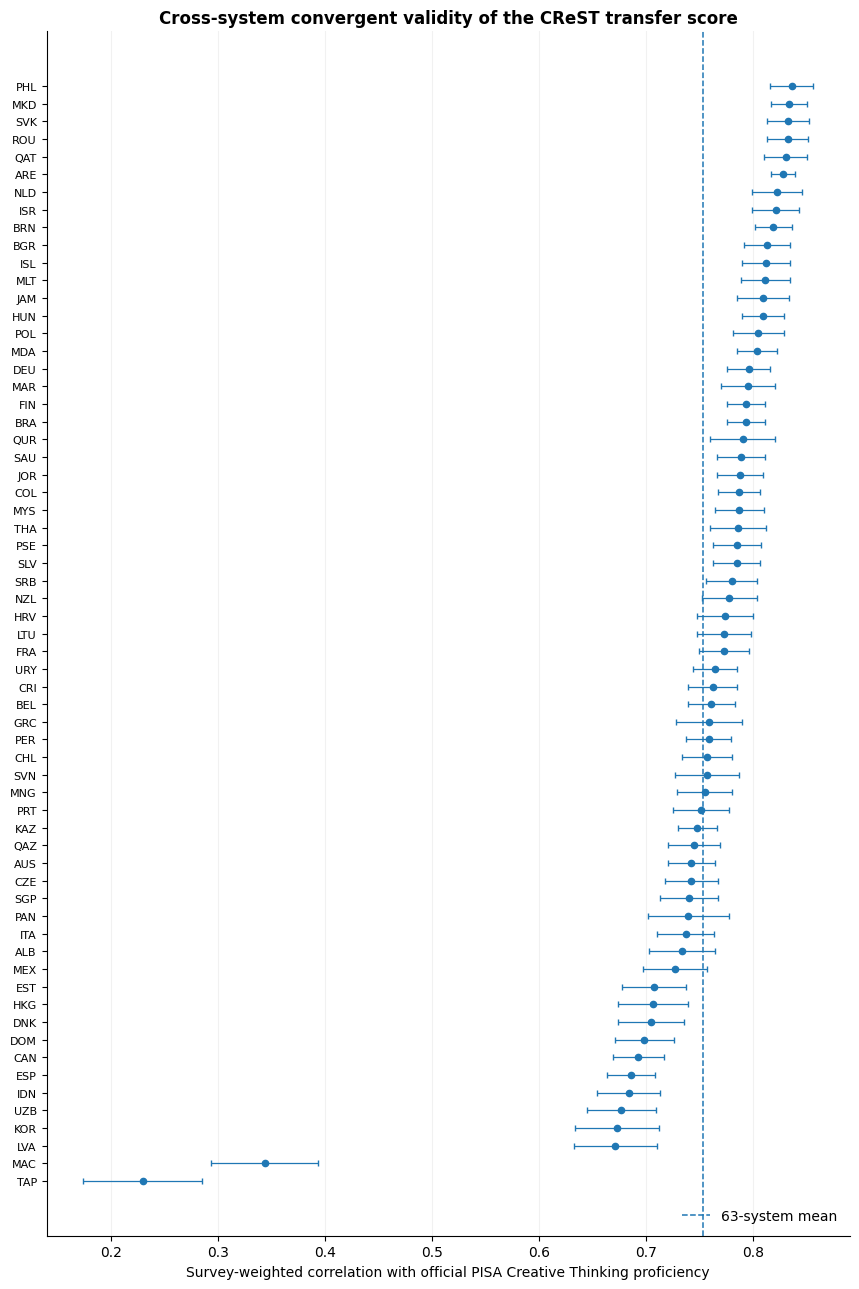

In [ ]:
# Cross-system convergent-validity figure

import matplotlib.pyplot as plt


validity_plot = (
    pv_validation_system_df
    .sort_values(
        "correlation",
        ascending=True
    )
    .reset_index(
        drop=True
    )
)


y = np.arange(
    len(
        validity_plot
    )
)


r = (
    validity_plot[
        "correlation"
    ]
    .to_numpy()
)


lower = (
    r
    -
    validity_plot[
        "ci_low"
    ].to_numpy()
)


upper = (
    validity_plot[
        "ci_high"
    ].to_numpy()
    -
    r
)


fig, ax = plt.subplots(
    figsize=(
        8.7,
        13.0
    )
)


ax.errorbar(
    r,
    y,
    xerr=np.vstack(
        [
            lower,
            upper
        ]
    ),
    fmt="o",
    markersize=4.5,
    capsize=2,
    linewidth=0.9
)


ax.axvline(
    validity_plot[
        "correlation"
    ].mean(),
    linestyle="--",
    linewidth=1.1,
    label=(
        "63-system mean"
    )
)


ax.set_yticks(
    y
)


ax.set_yticklabels(
    validity_plot[
        "country"
    ],
    fontsize=8
)


ax.set_xlabel(
    "Survey-weighted correlation with official PISA "
    "Creative Thinking proficiency"
)


ax.set_ylabel(
    ""
)


ax.set_title(
    "Cross-system convergent alignment of the CReST transfer score",
    fontweight="semibold"
)


ax.grid(
    axis="x",
    alpha=0.17
)

ax.grid(
    axis="y",
    visible=False
)


ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)


ax.legend(
    frameon=False,
    loc="lower right"
)


fig.tight_layout()


fig.savefig(
    FIG_DIR
    / "crest_pisa_ct_convergent_validity_63systems.pdf",
    bbox_inches="tight"
)


fig.savefig(
    FIG_DIR
    / "crest_pisa_ct_convergent_validity_63systems.png",
    dpi=400,
    bbox_inches="tight"
)


plt.show()